# Eval 

## Libs and paths

In [99]:
import pandas as pd
import numpy as np
import json
import os
import datetime as dt
import pickle
from unidecode import unidecode
from sklearn import metrics
from pytimeparse.timeparse import timeparse
import matplotlib.pyplot as plt
import shap
import time
import warnings
from sklearn.inspection import permutation_importance
from grouped_permutation_importance import grouped_permutation_importance
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.manifold import MDS

warnings.filterwarnings('ignore')

src_path = os.path.abspath(os.getcwd())
root_path = os.path.dirname(src_path)
# root_path = 'D:/Pedro/Desktop/Dropbox/UnB/Doc/projects/api_camara'

os.chdir(src_path)
import model
import build_features

In [100]:
data_path = os.path.join(root_path, 'dados')
raw_path = os.path.join(data_path, 'raw')
interim_path = os.path.join(data_path, 'interim')
processed_path = os.path.join(data_path, 'processed')
plots_path = os.path.join(processed_path, 'plots')
models_path = os.path.join(root_path, 'models')
config_path = os.path.join(root_path, 'config')

In [101]:
with open(os.path.join(config_path,'model.json'), encoding='latin1') as json_file:
    model_configs = json.load(json_file)  

rand = model_configs['random']
n_jobs = model_configs['jobs']
time_serie_split = model_configs['time_serie_split']
split_vote = model_configs['split_vote']
train_size = model_configs['train_size']
cv_method = model_configs['cv_method']

## Functions

In [102]:
def evaluate_model(y_pred_, y_test_):
    
    """
    Evaluates the performance of a machine learning model by calculating several metrics.

    Parameters:
    - y_pred_: Series or array of predicted values.
    - y_test_: Series or array of actual target values (ground truth).

    Returns:
    - metrics_dict: Dictionary containing accuracy, precision, recall, f1-score, kappa score, and the confusion matrix.
    """
    
    # Calculate accuracy, precision, recall, f1-score, and kappa score
    acc = metrics.accuracy_score(y_test_, y_pred_)                       #number of correctly classified
    prec = metrics.precision_score(y_test_, y_pred_,  pos_label='Sim')   #tp / (tp + fp) - ability of the classifier not to label as positive a sample that is negative.
    rec = metrics.recall_score(y_test_, y_pred_, pos_label='Sim')        #tp / (tp + fn) - ability of the classifier to find all the positive samples.
    f1 = metrics.f1_score(y_test_, y_pred_, pos_label='Sim')             #F1 = 2 * (precision * recall) / (precision + recall) - harmonic mean of the precision and recall
    kappa = metrics.cohen_kappa_score(y_test_, y_pred_)                  #measures inter-annotator agreement.
 
    # # Calculate area under curve (AUC)
    # y_pred_proba = model.predict_proba(x_test)[::,1]
    # fpr, tpr, _ = metrics.roc_curve(y_test_, y_pred_proba)
    # auc = metrics.roc_auc_score(y_test_, y_pred_proba)
    
    # Display confussion matrix
    cm = metrics.confusion_matrix(y_test_, y_pred_)
    
    metrics_dict = {'acc': acc, 
               'prec': prec,
               'rec': rec,
               'f1': f1,
               'kappa': kappa, 
               # 'fpr': fpr, 
               # 'tpr': tpr, 
               # 'auc': auc,
               'cm': cm
               }
    
    return metrics_dict

In [103]:
def unpack_dict(dict_metrics, flag):
    
    """
    Unpacks a dictionary of model metrics and formats them into DataFrames for further analysis.

    Parameters:
    - dict_metrics: Dictionary containing evaluation metrics and confusion matrices for different models.
    - flag: String representing a specific identifier (e.g., a label or category) to be added to the output DataFrames.

    Returns:
    - df_metric: DataFrame containing the unpacked evaluation metrics (excluding confusion matrix).
    - df_cm: DataFrame containing the unpacked confusion matrices.
    """
        
    df_metric = df_cm = pd.DataFrame()
    
    for flag_ in dict_metrics.keys():  
        for model_name, metric in dict_metrics[flag_].items():
            
            metric_f = {k:v for k,v in metric.items() if k!='cm'}
            metric_f[flag] = flag_
            metric_f['model'] = model_name
            df_metric_f = pd.DataFrame(metric_f, index = [0])
            df_metric = pd.concat([df_metric, df_metric_f])
            
            if len (metric['cm'])>1:
                df_cm_f = pd.DataFrame(metric['cm'], columns  = ['nao_pred','sim_pred'])
                df_cm_f['index'] = ['nao_true','sim_true'] 
                df_cm_f[flag] = flag_
                df_cm_f['model'] = model_name
                df_cm = pd.concat([df_cm, df_cm_f])
            
    return df_metric, df_cm

In [104]:
def plot_shap(model_fit, X_train, path, model_name, legis, version = 1):
    
    """
    Generates SHAP (SHapley Additive exPlanations) plots to explain the model's predictions.

    Parameters:
    - model_fit: Fitted machine learning model.
    - X_train: DataFrame of training features used to calculate SHAP values.
    - path: String representing the directory path to save the SHAP plot.
    - model_name: String representing the name of the model.
    - legis: String identifier (e.g., legislative session or group name) for the plot.
    - version: Integer representing the version of the SHAP plot (default: 1).

    Returns:
    - A string message "SHAP done" indicating that the SHAP plot has been generated and saved.
    """
    if model_name in ['rf', 'gbm']:
        explainer = shap.TreeExplainer(model_fit.best_estimator_, X_train)
        shap_values = explainer(X_train, check_additivity=False)    
    elif model_name == 'benchmark':
        explainer = shap.Explainer(model_fit, X_train)
        shap_values = explainer(X_train)        
    else:
        explainer = shap.Explainer(model_fit.best_estimator_, X_train)
        shap_values = explainer(X_train)
   
    file_name = f"shap_{model_name}_{legis}_v{version}.png"
    full_name = f"{path}/{file_name}"
    if file_name in os.listdir(path):
        print('.')
        os.remove(full_name)
        
    f = shap.summary_plot(shap_values, X_train, show=False)
    plt.savefig(full_name,dpi=150)        
    plt.show()        
    time.sleep(2)
    plt.close(f)    
    
    return "SHAP done"

In [105]:
def perm_importance(model_fit, X_test, y_test, n, rand, n_jobs):
    
    """
    Calculates the permutation importance of features in a machine learning model.

    Parameters:
    - model_fit: Fitted machine learning model.
    - X_test: DataFrame of testing features.
    - y_test: Series of actual target values.
    - n: Number of repetitions for permutation.
    - rand: Random seed for reproducibility.
    - n_jobs: Number of jobs to run in parallel for the computation.

    Returns:
    - Dictionary containing:
      - 'full': DataFrame with permutation importances for all repetitions.
      - 'mean': DataFrame with mean and standard deviation of permutation importances for each feature.
    """
    
    r = permutation_importance(model_fit, X_test, y_test, n_repeats=n, random_state=rand, n_jobs = n_jobs)

    sorted_importances_idx = r.importances_mean.argsort()
    df_importances_full = pd.DataFrame(
        r.importances[sorted_importances_idx].T,
        columns=X_test.columns[sorted_importances_idx],
        )
        
    df_importances_mean = pd.DataFrame({'var': X_test.columns[sorted_importances_idx],
                                        'importances_mean': r.importances_mean[sorted_importances_idx],
                                        'importances_std': r.importances_std[sorted_importances_idx]})
    
    return {'full': df_importances_full, 'mean':df_importances_mean}

In [106]:
def groupped_perm_importance(model_fit, X_test, y_test, dict_group, n, rand, n_jobs):
    
    """
    Calculates permutation importance of feature groups in a machine learning model.

    Parameters:
    - model_fit: Fitted machine learning model.
    - X_test: DataFrame of testing features.
    - y_test: Series of actual target values.
    - dict_group: Dictionary mapping group names to lists of feature names.
    - n: Number of repetitions for permutation.
    - rand: Random seed for reproducibility.
    - n_jobs: Number of jobs to run in parallel for the computation.

    Returns:
    - Dictionary containing:
      - 'full': DataFrame with permutation importances for each group across all repetitions.
      - 'mean': DataFrame with mean and standard deviation of permutation importances for each group.
    """
    idxs = []
    for key,cols in dict_group.items():
        idxs.append([X_test.columns.get_loc(col) for col in cols])
        
    r = grouped_permutation_importance(estimator = model_fit, 
                                       X= X_test.to_numpy(), 
                                       y = y_test.to_numpy(),
                                       idxs = idxs, 
                                       n_repeats=n, 
                                       random_state=rand,
                                       n_jobs = n_jobs,
                                       scoring = 'balanced_accuracy'
                                      )

    df_importances_full = pd.DataFrame(r.importances.T, columns=dict_group.keys())        
    df_importances_mean = pd.DataFrame({'var': dict_group.keys(),'importances_mean': r.importances_mean,'importances_std': r.importances_std})
    
    return {'full': df_importances_full, 'mean':df_importances_mean}

## Data

In [129]:
df_votos = pd.read_csv(os.path.join(interim_path, 'features.csv'), sep = ';')

In [130]:
#votes df
votes_dict = build_features.open_full_data('votacoes')  
df_votacoes_ = votes_dict['arquivos_votacoes_file']
df_votacoes_['idLegislatura'] = df_votacoes_['y'].apply(build_features.get_leg)
# df_vot_prop = votes_dict['arquivos_votacoesProposicoes_file'].copy()

In [131]:
cols = ['id', 'data','idLegislatura','y', 'aprovacao', 'votosSim','votosNao', 'votosOutros', 'descricao']
df_votacoes = df_votacoes_[cols]
df_votacoes = df_votacoes.rename(columns  = {'id':'idVotacao'})

In [132]:
df_vot_result = votes_dict['arquivos_votacoes_file']
df_vot_result = df_vot_result[['id','aprovacao', 'votosSim','votosNao', 'votosOutros']].rename(columns = {'id': 'idVotacao'})

In [133]:
df_vot_type = votes_dict['arquivos_votacoesProposicoes_file']
df_vot_type = df_vot_type.sort_values(['data']).groupby(['idVotacao'], as_index=False).last()[['idVotacao','proposicao_siglaTipo']]
df_vot_type.columns = ['idVotacao', 'tipo_votacao']

In [134]:
df_vot_type = df_votos.merge(df_vot_type, how='left', on = 'idVotacao')
df_vot_type = df_vot_type[['idVotacao', 'tipo_votacao']].drop_duplicates()

In [135]:
dict_meta = pd.read_excel(os.path.join(interim_path, 'metadata.xlsx'), sheet_name = None)
df_meta = dict_meta['metadata']

In [136]:
target = df_meta[df_meta['type'] == 'Target']['var'].item()
id_cols  = df_meta[df_meta['type'] == 'Index']['var'].to_list()    
features = df_meta[df_meta['type'] == 'Features']['var'].to_list()

In [137]:
df_meta_tipo_vot = dict_meta['tipo'].sort_values('Rank').drop('Rank', axis=1)
df_meta_tipo_vot.columns = ['projeto', 'tipo_votacao', 'tipo_aprovacao']

df_meta_quorum_vot = dict_meta['quorum']
df_meta_quorum_vot.columns = ['tipo_aprovacao', 'votos_necessarios']

df_vot_quorum = df_meta_tipo_vot.merge(df_meta_quorum_vot, how='left',  on = 'tipo_aprovacao').drop('projeto', axis=1)

In [138]:
df_vot_type = df_vot_type.merge(df_vot_quorum, how='left' , on ='tipo_votacao')

In [139]:
df_vot_meta = df_vot_type.merge(df_vot_result, how='left', on = ['idVotacao'])

In [140]:
df_vot_meta['votosTotais'] = df_vot_meta['votosSim'] + df_vot_meta['votosNao'] #+ df_vot_meta['votosOutros']

In [141]:
df_vot_meta.head()

,idVotacao,tipo_votacao,tipo_aprovacao,votos_necessarios,aprovacao,votosSim,votosNao,votosOutros,votosTotais
0,18156-127,PL,Maioria Absoluta,257.0,0.0,62.0,338.0,2.0,400.0
1,18156-148,PL,Maioria Absoluta,257.0,NaN,343.0,75.0,2.0,418.0
2,18156-152,PL,Maioria Absoluta,257.0,NaN,390.0,52.0,1.0,442.0
3,18156-154,PL,Maioria Absoluta,257.0,0.0,63.0,383.0,2.0,446.0
4,18156-156,PL,Maioria Absoluta,257.0,0.0,53.0,364.0,2.0,417.0


In [142]:
df_vt_type = dict_meta['tipo']
ids = df_votos[df_votos.idLegislatura.isin([52,53,54,55,56])]['idVotacao'].unique()
# # df_vt_type = df_vt_type[df_vt_type.idVotacao.isin(ids)]


In [143]:
# df_vt_type = df_vt_type.merge(df_vot_meta[df_vot_meta.idVotacao.isin(ids)].groupby('tipo_votacao', as_index=False).size(),how='left', on = 'tipo_votacao')
# df_vt_type = df_vt_type.groupby(['projeto', 'tipo_aprovacao'], as_index=False).sum().sort_values('size', ascending=False)
# df_vt_type = df_vt_type.merge(dict_meta['quorum'],how='left', on = 'tipo_aprovacao')

In [144]:
aux = df_votos[df_votos.idLegislatura.isin([52,53,54,55,56])].groupby('idLegislatura', as_index=False).size().rename(columns = {'size': 'votes'})
aux1 = df_votos[df_votos.idLegislatura.isin([52,53,54,55,56])][['idLegislatura','idVotacao']].drop_duplicates().groupby('idLegislatura', as_index=False).size().rename(columns = {'size': 'votings'})
aux2 = df_votos[df_votos.idLegislatura.isin([52,53,54,55,56])][['idLegislatura','idProposicao']].drop_duplicates().groupby('idLegislatura', as_index=False).size().rename(columns = {'size': 'propositions'})
aux3 = df_votos[df_votos.idLegislatura.isin([52,53,54,55,56])][['idLegislatura','idDeputado']].drop_duplicates().groupby('idLegislatura', as_index=False).size().rename(columns = {'size': 'deputies'})

In [145]:
for ax in [aux2, aux1, aux3]:
    aux = aux.merge(ax, how='left', on = 'idLegislatura')

In [146]:
# print(aux.to_latex())

In [147]:
# aux.sum()

In [148]:
for c in ['idVotacao', 'idProposicao', 'idDeputado']:
    c_ = df_votos[df_votos.idLegislatura.isin([52,53,54,55,56])][c].drop_duplicates()
    print(c, c_.shape)

idVotacao (3727,)
idProposicao (1159,)
idDeputado (1732,)


In [149]:
aux_ = df_votos[df_votos.idLegislatura.isin([52,53,54,55,56])][id_cols].merge(df_vot_meta[['idVotacao', 'tipo_votacao']].drop_duplicates(), how='left', on = 'idVotacao')

In [150]:
# aux_[['tipo_votacao', 'idVotacao']].drop_duplicates().groupby('tipo_votacao',as_index=False).size().sort_values('size', ascending=False)

In [151]:
mask = ((df_vot_meta['tipo_aprovacao'] == 'Maioria Simples') & (df_vot_meta['votosSim'] >= round(df_vot_meta['votosTotais']/2,0))) | \
       ((df_vot_meta['tipo_aprovacao'] != 'Maioria Simples') & (df_vot_meta['votosSim'] >= df_vot_meta['votos_necessarios']))
        
df_vot_meta.loc[mask, 'aprovacao_calculo'] = 1
df_vot_meta['aprovacao_calculo'] = df_vot_meta['aprovacao_calculo'].fillna(0)

In [152]:
df_vot_meta.loc[(df_vot_meta['aprovacao'] != df_vot_meta['aprovacao_calculo']) & ~(df_vot_meta['aprovacao'].isna()), 'flag_aprovacao'] = 1
df_vot_meta['flag_aprovacao'] = df_vot_meta['flag_aprovacao'].fillna(0)

In [153]:
df_vot_meta[df_vot_meta['flag_aprovacao'] == 1]

,idVotacao,tipo_votacao,tipo_aprovacao,votos_necessarios,aprovacao,votosSim,votosNao,votosOutros,votosTotais,aprovacao_calculo,flag_aprovacao
6,15460-165,PL,Maioria Absoluta,257.0,1.0,246.0,202.0,4.0,448.0,0.0,1.0
39,2180710-5,PL,Maioria Absoluta,257.0,1.0,237.0,27.0,87.0,264.0,0.0,1.0
42,18216-226,PL,Maioria Absoluta,257.0,1.0,232.0,122.0,3.0,354.0,0.0,1.0
63,125572-187,PLP,Maioria Absoluta,257.0,0.0,283.0,66.0,4.0,349.0,1.0,1.0
65,120186-68,PEC,(3/5),308.0,1.0,303.0,127.0,10.0,430.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
3218,2236326-19,CMC,Maioria Absoluta,257.0,1.0,233.0,170.0,8.0,403.0,0.0,1.0
3281,2311542-30,PEC,(3/5),308.0,1.0,300.0,144.0,2.0,444.0,0.0,1.0
3292,2312447-5,PEC,(3/5),308.0,1.0,293.0,129.0,1.0,422.0,0.0,1.0
3370,2293449-174,PEC,(3/5),308.0,1.0,307.0,143.0,2.0,450.0,0.0,1.0


In [154]:
dict_rename = {'Index': 'Index',
               'Target': 'Target',
               'Votação': 'Voting',
               'Política': 'Politics',
               'Proposição': 'Proposition',
               'Deputado': 'Deputy'}

df_meta['grupo_'] = df_meta['grupo']
for x,y in dict_rename.items():
    df_meta.loc[df_meta['grupo_'] == x, 'grupo_'] = y

In [155]:
dict_rename = {'Index': 'Index',
                 'Target': 'Target',
                 'Histórico de votação': 'Voting history',
                 'Conjuntura política': 'Political circumstances',
                 'Características de proposição': 'Proposition characteristics',
                 'Características de origem do deputado': 'Source characteristics of deputy',
                 'Habilidade política': 'Political skills',
                 'Relação deputado - proposição': 'Relationship deputy - proposition',
                 'Origem da proposição': 'Source of proposition',
                 'Produtividade parlamentar': 'Parliamentary productivity'}

df_meta['subgrupo_'] = df_meta['subgrupo']
for x,y in dict_rename.items():
    df_meta.loc[df_meta['subgrupo_'] == x, 'subgrupo_'] = y

In [156]:
# df_meta[['grupo_', 'subgrupo_']].drop_duplicates()

In [157]:
df_group = df_meta[~df_meta['grupo_'].isin(['Index', 'Target'])]['grupo_'].value_counts().to_frame().reset_index()
df_subgroup = df_meta[~df_meta['subgrupo_'].isin(['Index', 'Target'])]['subgrupo_'].value_counts().to_frame().reset_index()

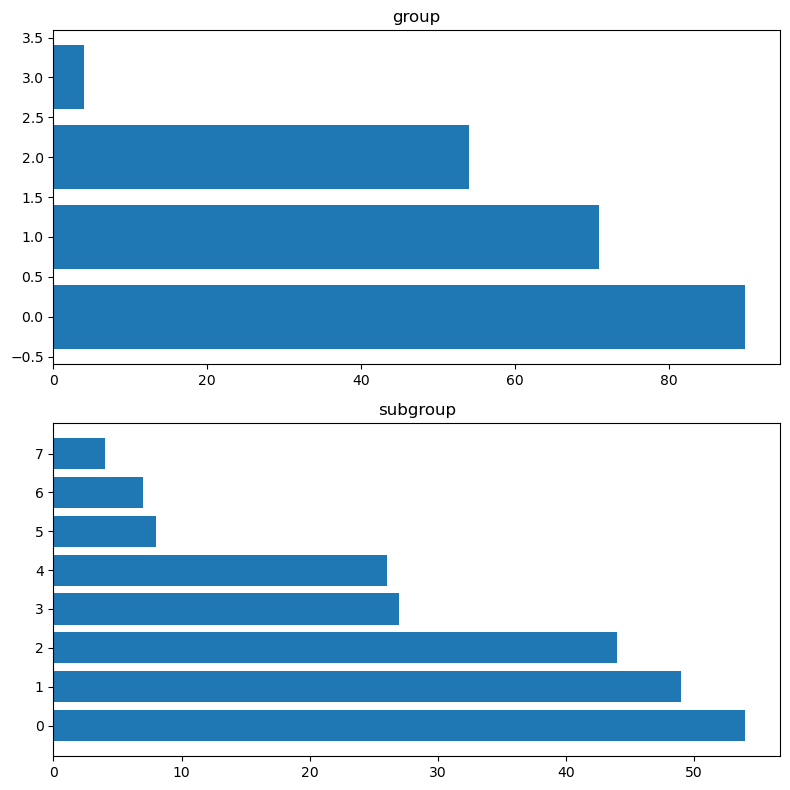

In [158]:
fig, ax = plt.subplots(nrows = 2, figsize=(8,8))    
ax[0].barh(df_group.index,df_group['grupo_'])
ax[0].set_title('group')
ax[1].barh(df_subgroup.index,df_subgroup['subgrupo_'])
ax[1].set_title('subgroup')
fig.tight_layout()        
plt.savefig(os.path.join(plots_path, 'features_groups.png'))
plt.show()

In [159]:
# df_subgroup = df_meta[~df_meta['subgrupo'].isin(['Index', 'Target'])]['subgrupo'].value_counts().to_frame()
# df_subgroup.plot.barh(title = 'No. variáveis por subgrupo')

In [160]:
df_votos.head(5)

,idDeputado,nome,siglaUf,idPartido,siglaPartido,data,y,idLegislatura,idProposicao,idVotacao,...,d_prof_servico_publico,d_prof_artes,d_prof_pedagogia,d_prof_comunicacao,d_prof_medicina,d_prof_militar,d_prof_religiao,d_prof_trabalhista,d_prof_comercial,d_prof_tecnico
0,204521.0,Abou Anni,SP,36837.0,PSL,2021-05-04,2021,56.0,18156.0,18156-127,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,204379.0,Acácio Favacho,AP,36763.0,PROS,2021-05-04,2021,56.0,18156.0,18156-127,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,204528.0,Adriana Ventura,SP,37901.0,NOVO,2021-05-04,2021,56.0,18156.0,18156-127,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,121948.0,Adriano do Baldy,GO,37903.0,PP,2021-05-04,2021,56.0,18156.0,18156-127,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,74646.0,Aécio Neves,MG,36835.0,PSDB,2021-05-04,2021,56.0,18156.0,18156-127,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [161]:
df_votos[target].value_counts()
df_votos = df_votos[df_votos[target].isin(['Sim','Não'])]
df_votos = df_votos.sort_values(['data', 'y', 'idProposicao', 'idVotacao', 'idDeputado'])

In [162]:
#time df
df_time = pd.read_excel(os.path.join(processed_path, 'time/time.xlsx'))
df_time['seconds'] = df_time['time'].apply(lambda x: timeparse(x))
df_time['minutes'] = df_time['seconds']/60 

df_time_ = df_time[['legis', 'model', 'seconds', 'minutes', 'size_train', 'size_test']]
df_time_['idLegislatura'] = df_time_['legis'].astype(str)
df_time_ = df_time_.drop('legis', axis=1)

In [9]:
df_bloco = pd.read_csv(os.path.join(interim_path,'blocos_partidarios.csv'),sep =';')
df_bloco.loc[df_bloco['siglaPartido'] == 'PMDB','siglaPartido'] = 'MDB'

In [48]:
cols = ['idDeputado', 'nome', 'idPartido', 'siglaPartido', 'data', 'idLegislatura', 'idVotacao','voto']
df_votos = pd.read_csv(os.path.join(interim_path, 'features.csv'), sep = ';', usecols=cols)
df_votos.loc[df_votos['siglaPartido'] == 'PMDB','siglaPartido'] = 'MDB'

In [11]:
pct_votes = .6
pct_dep = .6

In [12]:
n_rows = 2
n_cols = 3
size = 5

In [13]:
coord_list = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1,2), (2,0)]

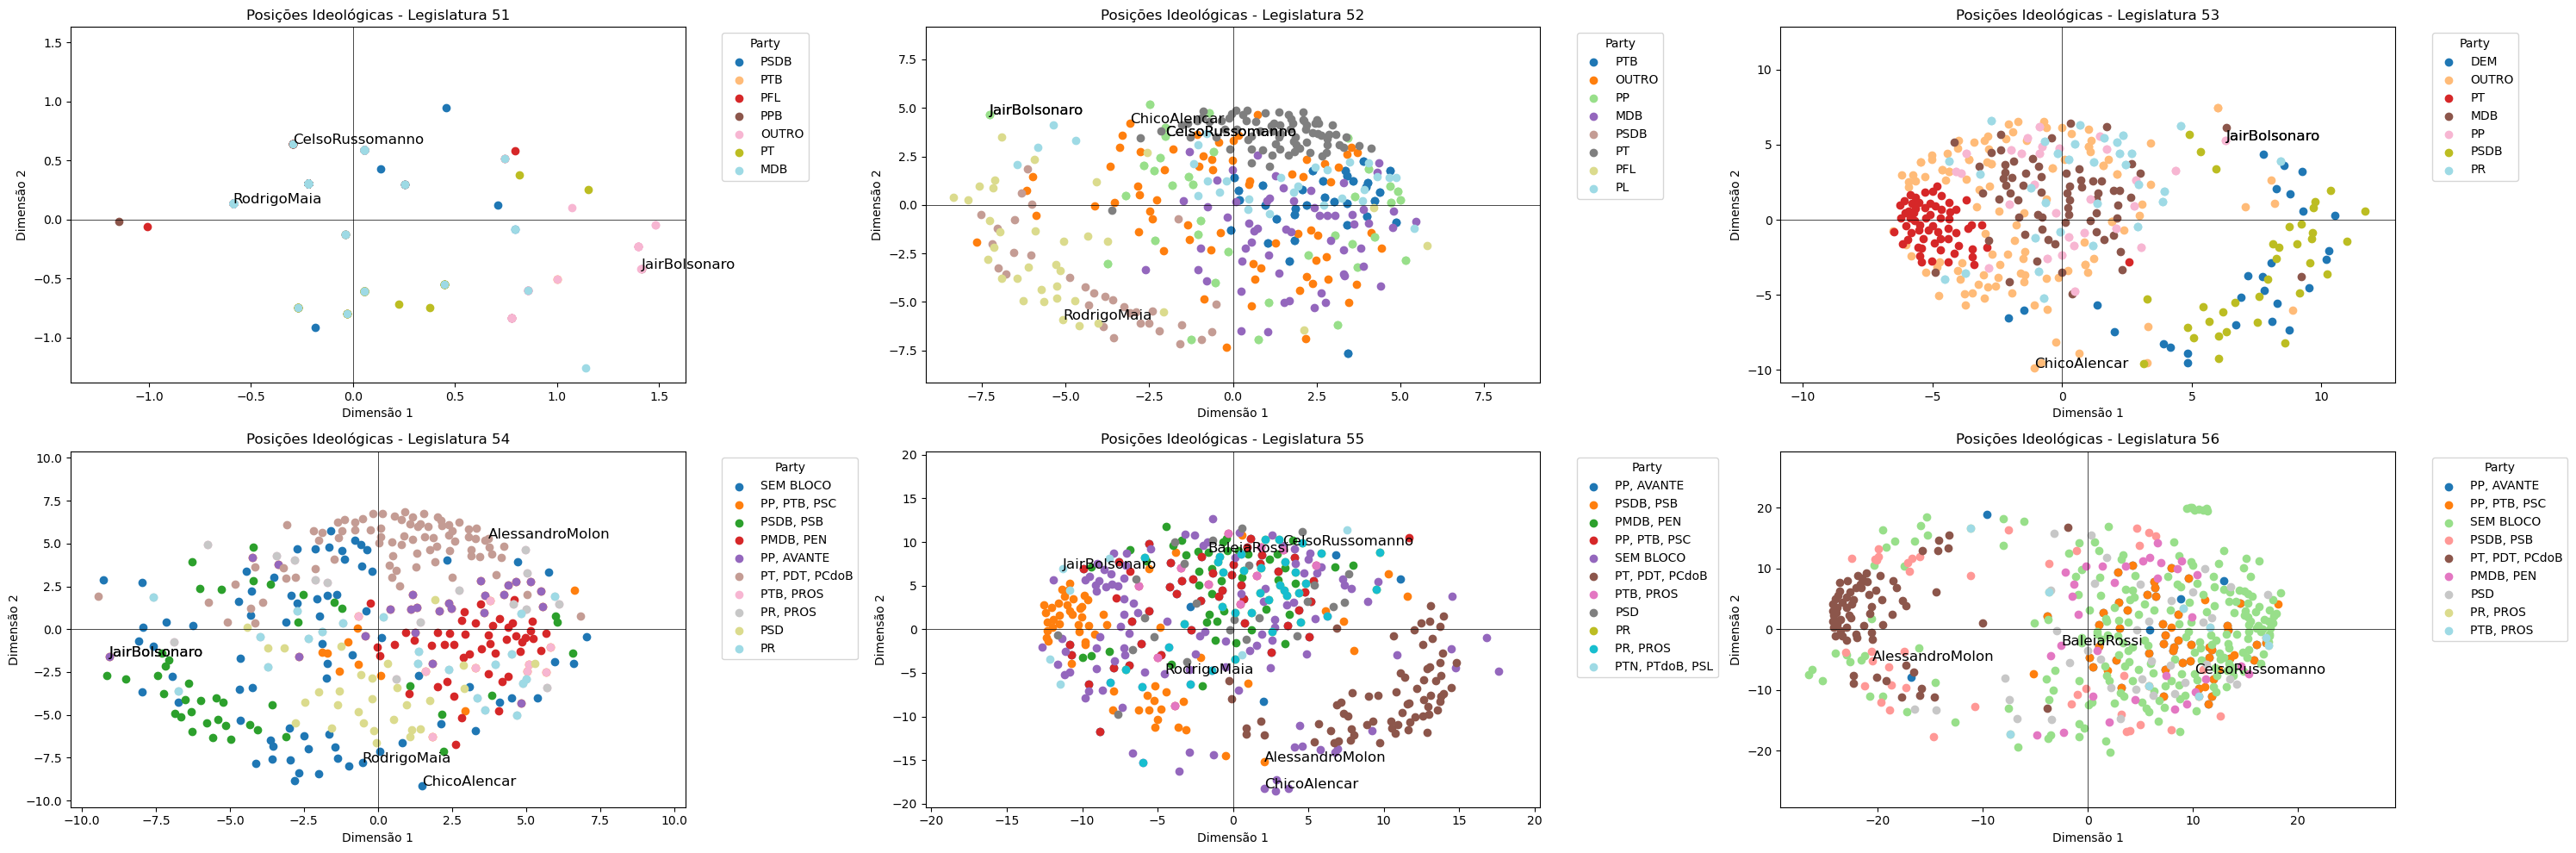

In [17]:
fig, axs = plt.subplots(n_rows, n_cols, figsize=(2 * size * n_cols, size * n_rows))
legis_list = sorted(df_votos['idLegislatura'].unique())[:-1]
for i,legis in enumerate(legis_list):
    
    df_votos_f = df_votos[df_votos['idLegislatura'] == legis]    
    df_party  = df_votos_f.sort_values(['idDeputado','data'])[['nome', 'siglaPartido']].drop_duplicates().groupby('nome', as_index=False).last()
    df_votos_f = df_votos_f.drop('siglaPartido',axis=1).merge(df_party,how='left', on = 'nome')
    
    df_vot_size = df_votos_f['idVotacao'].value_counts().reset_index()
    df_vot_size.columns = ['idVotacao', 'size']
    df_vot_size['pct'] = df_vot_size['size']/513
    list_vote_id = df_vot_size[df_vot_size['pct']>pct_votes]['idVotacao']
    
    df_dep_size = df_votos_f[df_votos_f['idVotacao'].isin(list_vote_id)][['idDeputado','nome']].value_counts().reset_index().rename(columns = {0:'size'})
    df_dep_size['pct'] = df_dep_size['size']/len(list_vote_id)
    list_dep_id = df_dep_size[df_dep_size['pct']>pct_dep]['idDeputado']
        
    df_votos_f = df_votos_f[(df_votos_f['idVotacao'].isin(list_vote_id)) & (df_votos_f['idDeputado'].isin(list_dep_id))]
    
    mapping_votes = {'Não': 0, 'Sim': 1, 'Artigo 17': np.nan, 'Abstenção': np.nan , 'Obstrução': -.5}
    df_votos_f['vote'] = df_votos_f['voto'].replace(mapping_votes)

    id_cols = ['idDeputado', 'nome', 'siglaPartido']
    df = df_votos_f.pivot(index=id_cols, columns='idVotacao', values='vote').fillna(.5)
    
    # Aplicar MDS
    mds1 = MDS(n_components=1, dissimilarity='euclidean', random_state=42)
    positions1 = mds1.fit_transform(df.to_numpy())
    positions1_df = pd.DataFrame(positions1, columns=['ideologia'],index=df.index).reset_index().sort_values('ideologia')

    mds = MDS(n_components=2, dissimilarity='euclidean', random_state=42)
    positions = mds.fit_transform(df.to_numpy())
    
    # Criar um DataFrame para as posições calculadas
    df_bloco_f = df_bloco[df_bloco['idLegislatura'] == 55].drop('idLegislatura',axis=1)
    positions_df = pd.DataFrame(positions, columns=['dim1', 'dim2'],index=df.index).reset_index()
    
    party_size = positions_df[['siglaPartido']].value_counts().to_frame().reset_index().rename(columns = {0:'size'})
    party_size['party']=party_size[['siglaPartido']]
    party_size.loc[party_size['size']<20,'party'] = 'OUTRO'
    
    positions_df=positions_df.merge(party_size, how='left', on = 'siglaPartido')
    positions_df=positions_df.merge(df_bloco_f, how='left', on = 'siglaPartido')
    positions_df['nome_'] = positions_df['nome_'].fillna('SEM BLOCO')
    
    flag_party = False if legis >= 54 else True
    col = 'party' if flag_party else 'nome_'
    
    items = positions_df[col].unique()
    cmap = plt.get_cmap('tab20')  # Escolhendo uma colormap com cores distintas
    colors = cmap(np.linspace(0, 1, len(items)))
    dict_colors = {item: color for item, color in zip(items, colors)}

    print_names = True
    names = ['Alessandro Molon', 'Baleia Rossi', 'Celso Russomanno', 'Chico Alencar',  'Jair Bolsonaro', 'Rodrigo Maia']
    # names = ['Glauber Braga', 'Ivan Valente', 'Chico Alencar', 'Weliton Prado', 'Luiza Erundina', 'Edmilson Rodrigues']
    
    coord = coord_list[i]
    
    for item, color in dict_colors.items():
        party_members = positions_df[positions_df[col] == item]
        axs[coord].scatter(party_members['dim1'], party_members['dim2'], color=color, label=item)
    
    min_value = min(positions_df[['dim1', 'dim2']].min())
    max_value = max(positions_df[['dim1', 'dim2']].abs().max())
    
    if print_names:
        for i, row in positions_df.iterrows():
            if row['nome'] in names:
                axs[coord].text(row['dim1'], row['dim2'], row['nome'].replace(' ', ''), fontsize=12,)    
    
    axs[coord].axhline(0, color='black', linewidth=0.5)
    axs[coord].axvline(0, color='black', linewidth=0.5)
    
    axs[coord].set_xlim(min_value*1.1, max_value*1.1)
    axs[coord].set_ylim(min_value*1.1, max_value*1.1)
    
    axs[coord].legend(title='Party', bbox_to_anchor=(1.05, 1), loc='upper left')
    axs[coord].set_title(f'Posições Ideológicas - Legislatura {int(legis)}')
    axs[coord].set_xlabel('Dimensão 1')
    axs[coord].set_ylabel('Dimensão 2')
    # plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(plots_path, f'ideology.png'),dpi=500)
plt.show()

In [50]:
df_votos['year'] = pd.to_datetime(df_votos['data']).dt.year

In [51]:
n_rows = 3
n_cols = 3
size = 5

In [52]:
coord_list = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1,2), (2,0), (2,1), (2,2)]

In [83]:
pct_votes = .4
pct_dep = .6

2014 0.39
2015 0.15
2016 0.31
2017 0.28
2018 0.4
2019 0.21
2020 0.16
2021 0.16
2022 0.28


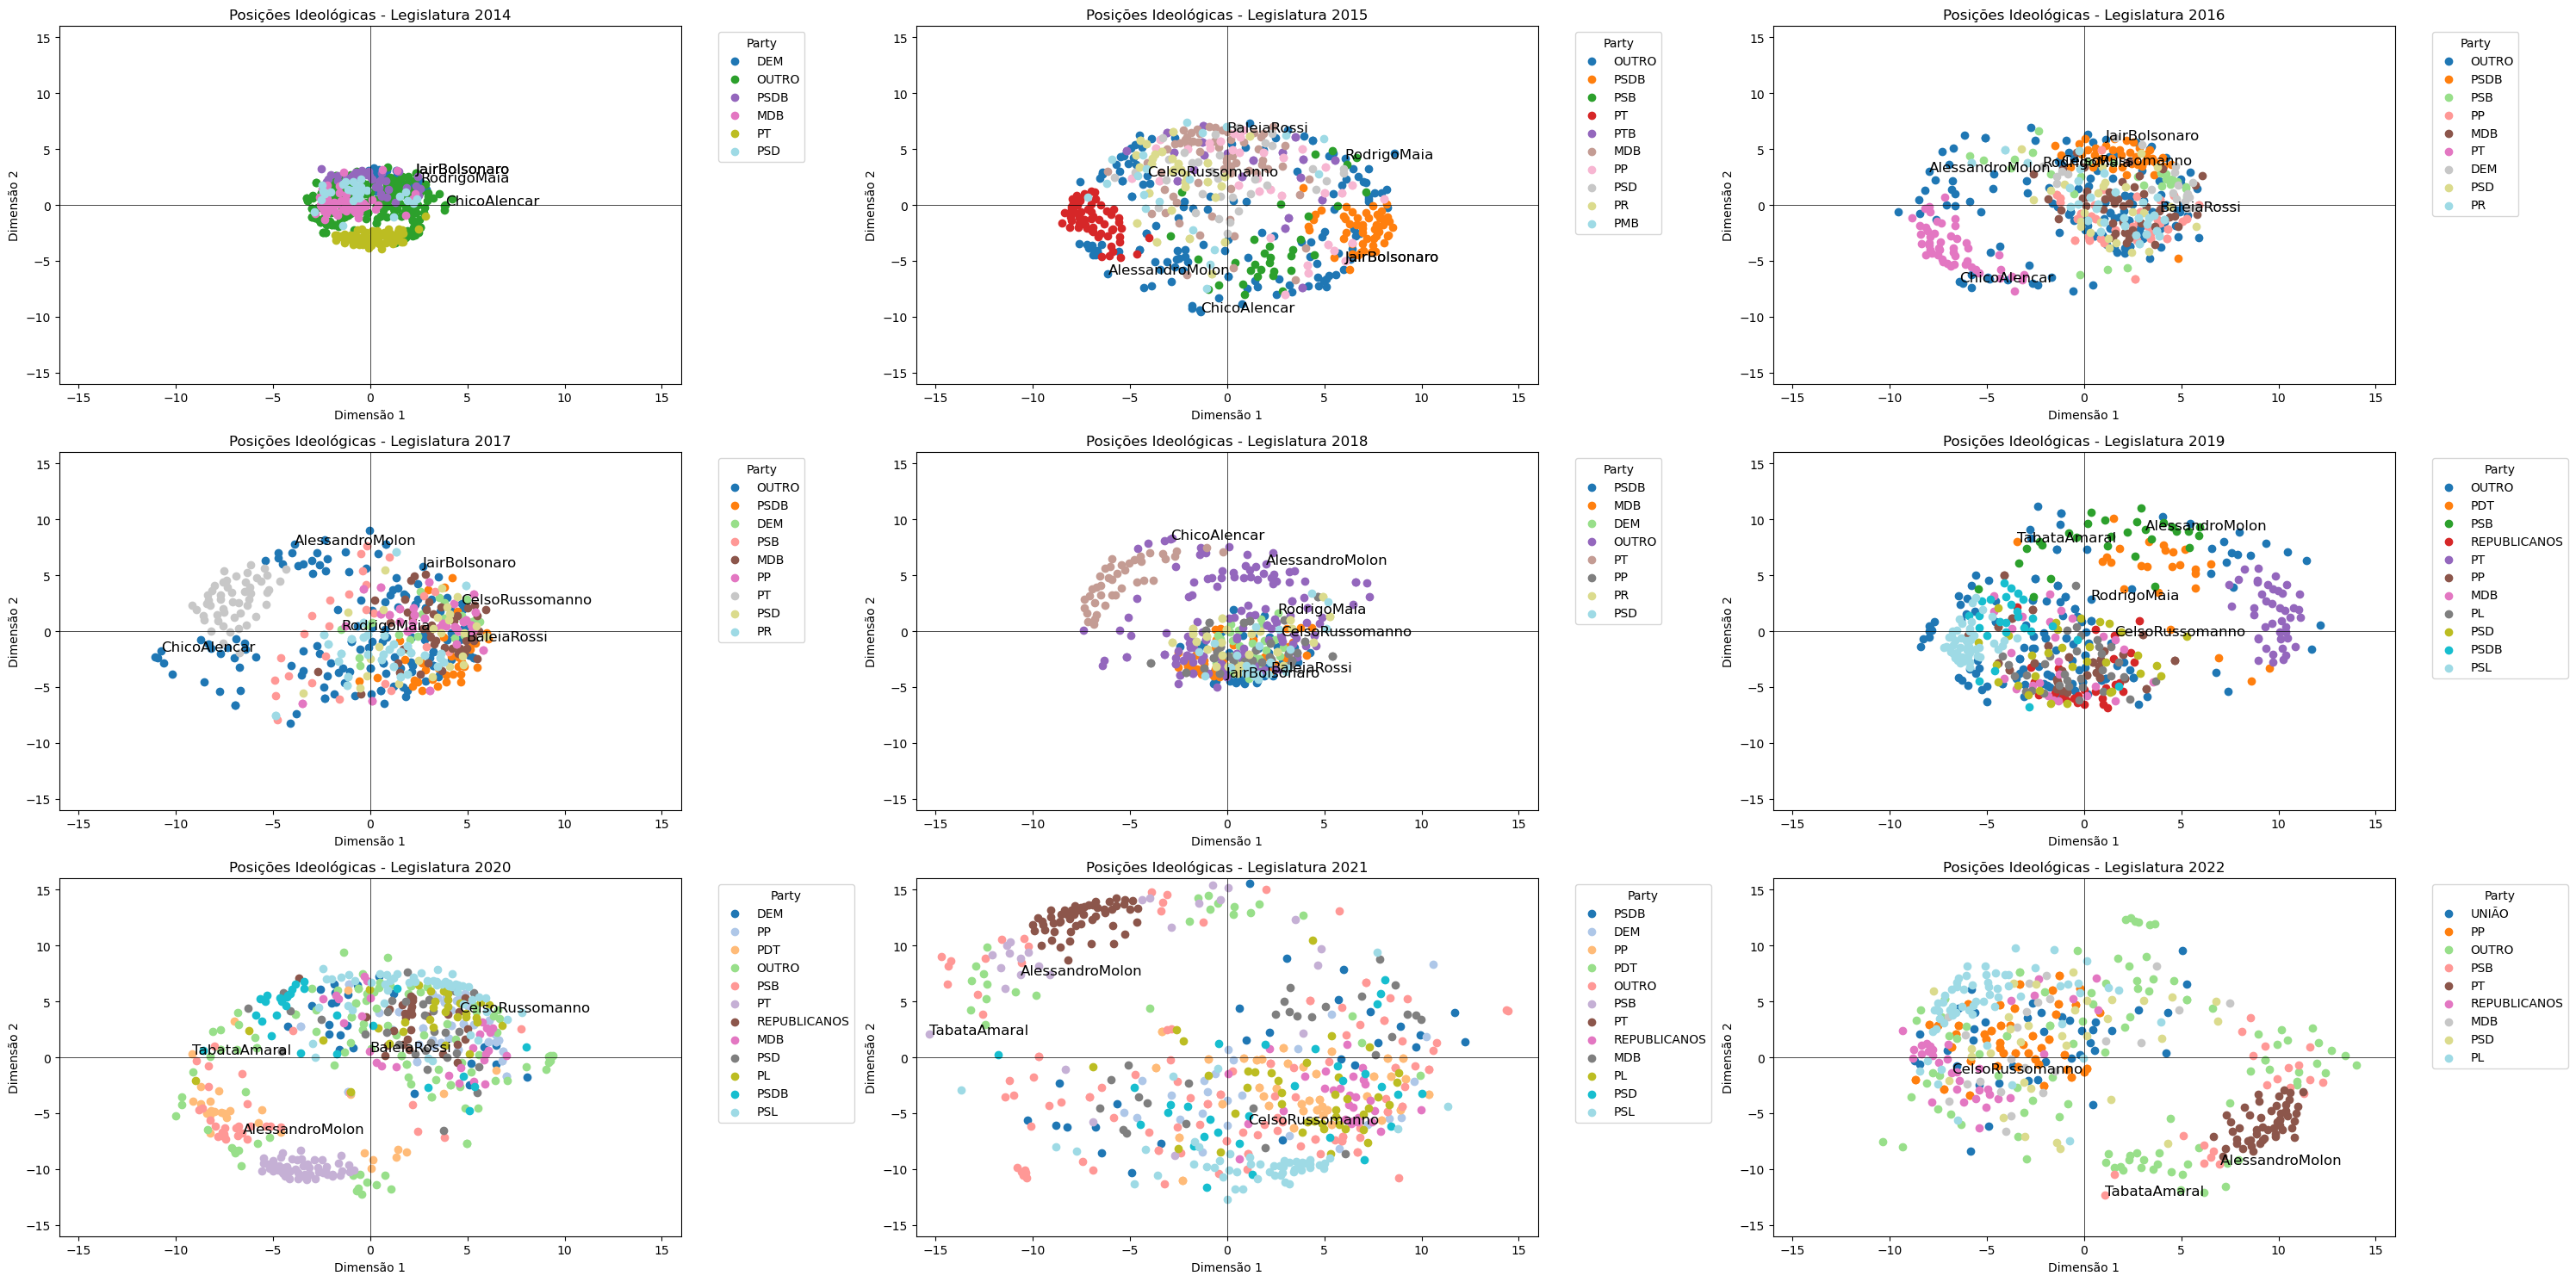

In [98]:
sorted(df_votos['year'].unique())

fig, axs = plt.subplots(n_rows, n_cols, figsize=(2 * size * n_cols, size * n_rows))
year_list =  [2014,2015,2016,2017, 2018, 2019, 2020, 2021, 2022]
for i,year in enumerate(year_list):
    
    
    df_votos_f = df_votos[df_votos['year'] == year]    
    df_party  = df_votos_f.sort_values(['idDeputado','data'])[['nome', 'siglaPartido']].drop_duplicates().groupby('nome', as_index=False).last()
    df_votos_f = df_votos_f.drop('siglaPartido',axis=1).merge(df_party,how='left', on = 'nome')
    
    df_vot_size = df_votos_f['idVotacao'].value_counts().reset_index()
    df_vot_size.columns = ['idVotacao', 'size']
    df_vot_size['pct'] = df_vot_size['size']/513
    list_vote_id = df_vot_size[df_vot_size['pct']>pct_votes]['idVotacao']
    
    df_dep_size = df_votos_f[df_votos_f['idVotacao'].isin(list_vote_id)][['idDeputado','nome']].value_counts().reset_index().rename(columns = {0:'size'})
    df_dep_size['pct'] = df_dep_size['size']/len(list_vote_id)
    list_dep_id = df_dep_size[df_dep_size['pct']>pct_dep]['idDeputado']
        
    print(year, round(len(df_dep_size[df_dep_size['pct']<=pct_dep])/len(df_dep_size), 2))        
        
    df_votos_f = df_votos_f[(df_votos_f['idVotacao'].isin(list_vote_id)) & (df_votos_f['idDeputado'].isin(list_dep_id))]
    
    mapping_votes = {'Não': 0, 'Sim': 1, 'Artigo 17': np.nan, 'Abstenção': np.nan , 'Obstrução': -.5}
    df_votos_f['vote'] = df_votos_f['voto'].replace(mapping_votes)

    id_cols = ['idDeputado', 'nome', 'siglaPartido']
    df = df_votos_f.pivot(index=id_cols, columns='idVotacao', values='vote').fillna(.5)
    
    # Aplicar MDS
    mds1 = MDS(n_components=1, dissimilarity='euclidean', random_state=42)
    positions1 = mds1.fit_transform(df.to_numpy())
    positions1_df = pd.DataFrame(positions1, columns=['ideologia'],index=df.index).reset_index().sort_values('ideologia')

    mds = MDS(n_components=2, dissimilarity='euclidean', random_state=42)
    positions = mds.fit_transform(df.to_numpy())
    
    # Criar um DataFrame para as posições calculadas
    df_bloco_f = df_bloco[df_bloco['idLegislatura'] == 55].drop('idLegislatura',axis=1)
    positions_df = pd.DataFrame(positions, columns=['dim1', 'dim2'],index=df.index).reset_index()
    
    party_size = positions_df[['siglaPartido']].value_counts().to_frame().reset_index().rename(columns = {0:'size'})
    party_size['party']=party_size[['siglaPartido']]
    party_size.loc[party_size['size']<20,'party'] = 'OUTRO'
    
    positions_df=positions_df.merge(party_size, how='left', on = 'siglaPartido')
    positions_df=positions_df.merge(df_bloco_f, how='left', on = 'siglaPartido')
    positions_df['nome_'] = positions_df['nome_'].fillna('SEM BLOCO')
    
    flag_party = False 
    col = 'party'
    
    items = positions_df[col].unique()
    cmap = plt.get_cmap('tab20')  # Escolhendo uma colormap com cores distintas
    colors = cmap(np.linspace(0, 1, len(items)))
    dict_colors = {item: color for item, color in zip(items, colors)}

    print_names = True
    names = ['Alessandro Molon', 'Baleia Rossi', 'Celso Russomanno', 'Chico Alencar',  'Jair Bolsonaro', 'Rodrigo Maia', "Tabata Amaral"]
    # names = ['Glauber Braga', 'Ivan Valente', 'Chico Alencar', 'Weliton Prado', 'Luiza Erundina', 'Edmilson Rodrigues']
    
    coord = coord_list[i]
    
    for item, color in dict_colors.items():
        party_members = positions_df[positions_df[col] == item]
        axs[coord].scatter(party_members['dim1'], party_members['dim2'], color=color, label=item)
    
    min_value = min(positions_df[['dim1', 'dim2']].min())
    max_value = max(positions_df[['dim1', 'dim2']].abs().max())
    
    if print_names:
        for i, row in positions_df.iterrows():
            if row['nome'] in names:
                axs[coord].text(row['dim1'], row['dim2'], row['nome'].replace(' ', ''), fontsize=12,)    
    
    axs[coord].axhline(0, color='black', linewidth=0.5)
    axs[coord].axvline(0, color='black', linewidth=0.5)
    
#     axs[coord].set_xlim(min_value*1.1, max_value*1.1)
#     axs[coord].set_ylim(min_value*1.1, max_value*1.1)

    axs[coord].set_xlim(-16,16)
    axs[coord].set_ylim(-16,16)
    
    axs[coord].legend(title='Party', bbox_to_anchor=(1.05, 1), loc='upper left')
    axs[coord].set_title(f'Posições Ideológicas - Legislatura {int(year)}')
    axs[coord].set_xlabel('Dimensão 1')
    axs[coord].set_ylabel('Dimensão 2')
    # plt.grid(True)

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, f'ideology.png'),dpi=500)
plt.show()

## Results

In [46]:
model_files = os.listdir(models_path)
legis_list = list({x.split('_')[-1].split('.')[0] for x in model_files})
legis_list = [x for x in legis_list if x!='old' and x!='v2' and x!='overall']

In [171]:
metrics_cols = ['acc', 'prec', 'rec', 'f1', 'kappa']

### V1 - Full features

#### Open results

In [ ]:
version = 1
show_shap = False
show_importance = True

In [ ]:
metrics_legis_dict = {x:{} for x in legis_list}
importance_dict = {x:{} for x in legis_list}
hyperparams_dict = {x:{} for x in legis_list}
g_importance_dict = {x:{} for x in legis_list}
g_importance_dict2 = {x:{} for x in legis_list}
y_test_agg = pd.DataFrame()

In [ ]:
# Open models e calculate metrics
df_size = pd.DataFrame()
for legis in sorted(legis_list):

    models = [x for x in model_files if legis in x and 'v2' not in x]
    print(models)
    metrics_legis_dict[legis] = {}
    importance_dict[legis] = {}
    g_importance_dict[legis] = {}
    g_importance_dict2[legis] = {}
    hyperparams_dict[legis] = {}

    if legis == 'overall':
        df_votos_f = df_votos.copy()
    else:
        df_votos_f = df_votos[df_votos['idLegislatura'] == int(legis)]

    df_std = df_votos_f.select_dtypes('number').std().reset_index()
    df_std.columns = ['var', 'std']

    df_std = df_std[~ df_std['var'].isin(id_cols + [target])]
    cols_to_drop = df_std[df_std['std'] == 0]['var'].to_list()

    df_votos_f = df_votos_f.drop(cols_to_drop,axis=1)

    X = df_votos_f.set_index(id_cols).drop(target,axis=1)
    y = df_votos_f.set_index(id_cols)[target]

    X_train, X_test, y_train, y_test = model.split_data(df_votos_f, X, y, train_size, id_cols, target, rand)
    # print(legis, X_train.shape, X_test.shape)
    
    dict_size  = {'legis': legis,'train_size': len(X_train), 'test_size': len(X_test), 'features': len(X.columns) }
    df_size = pd.concat([df_size, pd.DataFrame(dict_size, index=[0])])

    for f in models:
        y_test['legis_aux'] = legis

        model_fit = pickle.load(open(os.path.join(models_path, f), 'rb'))
        
        if len(f.split('_'))<4:
            model_name = f.split('_')[1]    
        else:
            model_name =  '_'.join(f.split('_')[1:3])

        print(f'opening {model_name} for legis {legis}...')

        if model_name == 'benchmark': 
            cols_ori = [x for x in X_train.columns if 'd_ori' in x]
            X_train_bench = X_train[cols_ori]
            X_test_bench = X_test[cols_ori]

            hyperparams_dict[legis][model_name] = {}

            pred_values = [x for x in model_fit.predict(X_test_bench)]
        else:
            try:
                hyperparams_dict[legis][model_name] = model_fit.best_params_
            except:
                pass
            pred_values = [x for x in model_fit.predict(X_test)]

        y_test[f'{target}_{model_name}'] =  pred_values            
        real_values = y_test[target].to_list()

        eval_dict = evaluate_model(pred_values, real_values)
        metrics_legis_dict[legis][model_name] = eval_dict

        if show_shap:
            if model_name in ['logit', 'gbm', 'rf']:
                plot_shap(model_fit, X_train, plots_path, model_name, legis)
            elif model_name == 'benchmark':
                 plot_shap(model_fit, X_train_bench, plots_path, model_name, legis)
            else:
                print(f'{model_name} {legis} could not use SHAP')

        n_rep = 30
        if show_importance and 'VC' not in model_name and 'knn' not in model_name and 'bench' not in model_name:            
            cols = X_test.columns.to_list()
            df_meta_ = df_meta[df_meta['var'].isin(cols)][['var', 'grupo','subgrupo']].drop_duplicates() 

            dict_group_ = {x:df_meta_[df_meta_['grupo'] ==x]['var'].to_list() for x in df_meta_['grupo'].unique()}
            idxs = []
            for key,cols in dict_group_.items():
                idxs.append([X_test.columns.get_loc(col) for col in cols])

            dict_subgroup_ = {x:df_meta_[df_meta_['subgrupo'] ==x]['var'].to_list() for x in df_meta_['subgrupo'].unique()}
            idxs2 = []
            for key,cols in dict_subgroup_.items():
                idxs2.append([X_test.columns.get_loc(col) for col in cols])                
            try:
                dict_importance_f = perm_importance(model_fit, X_test, y_test[target], n_rep, rand, n_jobs)
                dict_g_importance_f = groupped_perm_importance(model_fit, X_test, y_test[target],idxs, n_rep, rand, n_jobs)
                dict_g_importance_f_ = groupped_perm_importance(model_fit, X_test, y_test[target],idxs2, n_rep, rand, n_jobs)
            except:
                n_rep = 10
                try:
                    dict_importance_f = perm_importance(model_fit, X_test, y_test[target], n_rep, rand, n_jobs)
                    dict_g_importance_f = groupped_perm_importance(model_fit, X_test, y_test[target],idxs, n_rep, rand, n_jobs)
                    dict_g_importance_f_ = groupped_perm_importance(model_fit, X_test, y_test[target],idxs, n_rep, rand, n_jobs)
                except:
                    print(f'{model_name} {legis} could not use feat import')

            if model_name == 'benchmark':
                feature_names = X_test_bench.columns.to_list()
                idxs = []
                columns = [x.replace('d_ori_','') for x in feature_names if len(x.split('_')) == 3]
                dict_importance_f = perm_importance(model_fit, X_test_bench, y_test[target], n_rep, rand, n_jobs)
                dict_g_importance_f = groupped_perm_importance(model_fit, X_test_bench, y_test[target],idxs, n_rep, rand, n_jobs)

            importance_dict[legis][model_name] = dict_importance_f
            g_importance_dict[legis][model_name] = dict_g_importance_f
            g_importance_dict2[legis][model_name] = dict_g_importance_f_
            
            for k,v in dict_importance_f.items():
                v.to_csv(os.path.join(processed_path,f'features/permutation_importance_{model_name}_{k}_{legis}_v1.csv'), index=False)
            for k,v in dict_g_importance_f.items():
                v.to_csv(os.path.join(processed_path,f'features/groupped_permutation_importance_{model_name}_{k}_{legis}_v1.csv'), index=False)
            for k,v in dict_g_importance_f_.items():
                v.to_csv(os.path.join(processed_path,f'features/subgroupped_permutation_importance_{model_name}_{k}_{legis}_v1.csv'), index=False)
                
    y_test = y_test.reset_index()
    y_test_agg = pd.concat([y_test_agg,y_test])

In [ ]:
with open(os.path.join(processed_path,'hyperparams/hyperparams_v1.json'), 'w', encoding='latin1') as f:
    json.dump(hyperparams_dict, f)

In [ ]:
dict_import = {}
for k in ['full', 'mean']:    
    df_import = pd.DataFrame()    
    for legis in importance_dict.keys():
        for model_name, dict_importance_f in importance_dict[legis].items():                
            df_ = dict_importance_f[k].copy()                
            df_['legis'] = legis
            df_['model_name'] = model_name                
            df_import = pd.concat([df_import,df_])                
    dict_import[k] = df_import  
    df_import.to_csv(os.path.join(processed_path, f'perm_importance_{k}_v{version}.csv'), index=False)

In [ ]:
dict_import = {}
for k in ['full', 'mean']:    
    df_import = pd.DataFrame()    
    for legis in g_importance_dict.keys():
        for model_name, dict_importance_f in g_importance_dict[legis].items():                
            df_ = dict_importance_f[k].copy()                
            df_['legis'] = legis
            df_['model_name'] = model_name                
            df_import = pd.concat([df_import,df_])                
    dict_import[k] = df_import  
    df_import.to_csv(os.path.join(processed_path, f'g_perm_importance_{k}_v{version}.csv'), index=False)

In [ ]:
dict_import = {}
for k in ['full', 'mean']:    
    df_import = pd.DataFrame()    
    for legis in g_importance_dict2.keys():
        for model_name, dict_importance_f in g_importance_dict2[legis].items():                
            df_ = dict_importance_f[k].copy()                
            df_['legis'] = legis
            df_['model_name'] = model_name                
            df_import = pd.concat([df_import,df_])                
    dict_import[k] = df_import  
    df_import.to_csv(os.path.join(processed_path, f'sg_perm_importance_{k}_v{version}.csv'), index=False)

In [ ]:
# with open(os.path.join(processed_path,'perm_importance.json'), 'w', encoding='latin1') as f:
#     json.dump(dict_import, f)

In [ ]:
df_metric_legis, df_cm_legis = unpack_dict(metrics_legis_dict, 'idLegislatura')
df_metric_legis = df_metric_legis.merge(df_time_, how='left', on = ['idLegislatura', 'model'])

In [ ]:
models = df_metric_legis['model'].drop_duplicates().to_list()
models = [x for x in models if 'svm' not in x]

 - Fill Voting Classifier model with RF

In [ ]:
y_test_agg = y_test_agg.merge(df_vot_meta[['idVotacao', 'tipo_votacao']], how='left', on = ['idVotacao'])

In [ ]:
for c in ['voto_VChard', 'voto_VCsoft']:
    y_test_agg.loc[y_test_agg[c].isna(),c] = y_test_agg['voto_rf']

 - Ensemble model 1: Choose best model by type of vote

In [ ]:
metric_ensemble = 'acc'

In [ ]:
df_ensemble_tp = pd.read_csv(os.path.join(processed_path, 'ensemble_vote_type.csv'))
df_ensemble_tp = df_ensemble_tp[df_ensemble_tp.metric == metric_ensemble][['type','model']]
df_ensemble_tp.columns = ['tipo_votacao', 'model']

In [ ]:
y_test_agg = y_test_agg.merge(df_ensemble_tp, how='left', on = 'tipo_votacao')

In [ ]:
for m in [x for x in models if 'bench' not in x]:
    y_test_agg.loc[y_test_agg['model'] == m, 'voto_ENStype'] = y_test_agg[f'voto_{m}']

In [ ]:
y_test_agg = y_test_agg.drop(['tipo_votacao','model'], axis=1)

 - Ensemble 2: RF for betrail rate < 10 and GBM for > 10

In [ ]:
df_f = df_votos[df_votos['pct_traiu_ori_part']>0.1][id_cols]
df_f['model'] = 'knn'

In [ ]:
y_test_agg = y_test_agg.merge(df_f, how='left', on = id_cols)
y_test_agg['model'] = y_test_agg['model'].fillna('rf') 

In [ ]:
for m in ['rf', 'knn']:
    y_test_agg.loc[y_test_agg['model'] == m, 'voto_ENStrail'] = y_test_agg[f'voto_{m}']

In [ ]:
y_test_agg = y_test_agg.drop(['model'], axis=1)

In [ ]:
legis_list = sorted(y_test_agg['idLegislatura'].unique())
metrics_legis_dict_ = {x:{} for x in legis_list}
models_ = [x for x in y_test_agg.columns if  target in x and x!=target]

for legis in legis_list:
    
    df_ = y_test_agg[y_test_agg['idLegislatura'] == legis]
    for model_name in models_:
        pred_values = df_[model_name]
        real_values = df_[target].to_list()

        eval_dict = evaluate_model(pred_values, real_values)
        metrics_legis_dict_[legis][model_name] = eval_dict

In [ ]:
df_metric_legis, df_cm_legis = unpack_dict(metrics_legis_dict_, 'idLegislatura')
df_metric_legis['idLegislatura'] = df_metric_legis['idLegislatura'].astype(int).astype(str)
df_metric_legis['model'] = df_metric_legis['model'].str.split('_').str[-1]
df_metric_legis = df_metric_legis.merge(df_time_, how='left', on = ['idLegislatura', 'model'])

In [ ]:
y_test_agg.to_csv(os.path.join(processed_path, f'forecast/predictions_v1.csv'), index=False)
df_metric_legis.to_csv(os.path.join(processed_path, f'metrics/metrics_legis_v1.csv'), index=False)
df_cm_legis.to_csv(os.path.join(processed_path, f'metrics/conf_matrix_legis_v1.csv'), index=False)

#### Eval

##### Eficiency

 -  EFICIENCY PLOT (TIME VS SIZE)

In [163]:
y_test_agg = pd.read_csv(os.path.join(processed_path, 'forecast/predictions_v1.csv')).drop_duplicates()
df_metric_legis = pd.read_csv(os.path.join(processed_path, 'metrics/metrics_legis_v1.csv')).drop_duplicates()
df_cm_legis = pd.read_csv(os.path.join(processed_path, 'metrics/conf_matrix_legis_v1.csv')).drop_duplicates()

In [167]:
models = df_metric_legis['model'].drop_duplicates().to_list()
models = [x for x in models if 'svm' not in x]

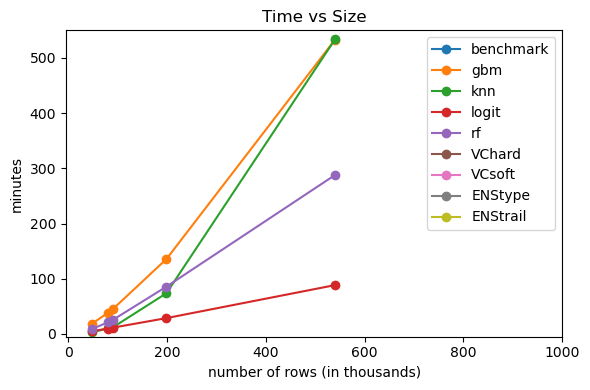

In [168]:
fig, axs = plt.subplots(figsize=(6,4))
axs.set_title('Time vs Size')
axs.set_ylabel('minutes')
axs.set_xlabel('number of rows (in thousands)')
axs.set_xlim(-5, 1000) 
axs.set_ylim(-5, 550) 

for i,mod in enumerate(models):
    df_f = df_metric_legis[df_metric_legis['model']==mod].sort_values('size_train')
    axs.plot(df_f['size_train']/1e3, df_f['minutes'], marker='o', label = f'{mod}')

fig.tight_layout()
plt.legend(loc='best')
# plt.savefig(os.path.join(plots_path, f'prob_skus_{abc}.png'))
plt.show()

##### Metrics overall

 -  METRICS PLOTS (METRIC VS MODEL (LEGIS))

In [169]:
df_metric_legis[df_metric_legis['model'].isin(['rf', 'ENStype', 'benchmark'])].sort_values(['idLegislatura', 'acc'], ascending = [True, False])[['idLegislatura', 'model', 'acc']]

,idLegislatura,model,acc
4,52,rf,0.924757
7,52,ENStype,0.923392
0,52,benchmark,0.919783
16,53,ENStype,0.929097
13,53,rf,0.927969
9,53,benchmark,0.927200
25,54,ENStype,0.922802
22,54,rf,0.922687
18,54,benchmark,0.913257
34,55,ENStype,0.907724


In [172]:
legis_list = sorted(df_metric_legis['idLegislatura'].unique())
for legis_ in legis_list:
    print(f'calculating best models for legis {legis_}')
    df_metrics_f = df_metric_legis[df_metric_legis['idLegislatura'] == legis_][metrics_cols + ['model']].set_index('model')
    for metric in metrics_cols:
        best_metric = df_metrics_f[metric].idxmax()
        print(f' - best model for {metric} is: {best_metric}')

calculating best models for legis 52
 - best model for acc is: rf
 - best model for prec is: VChard
 - best model for rec is: VCsoft
 - best model for f1 is: rf
 - best model for kappa is: rf
calculating best models for legis 53
 - best model for acc is: ENStype
 - best model for prec is: gbm
 - best model for rec is: rf
 - best model for f1 is: ENStype
 - best model for kappa is: ENStype
calculating best models for legis 54
 - best model for acc is: ENStype
 - best model for prec is: VCsoft
 - best model for rec is: gbm
 - best model for f1 is: ENStype
 - best model for kappa is: rf
calculating best models for legis 55
 - best model for acc is: ENStype
 - best model for prec is: VChard
 - best model for rec is: rf
 - best model for f1 is: rf
 - best model for kappa is: ENStype
calculating best models for legis 56
 - best model for acc is: rf
 - best model for prec is: rf
 - best model for rec is: ENStype
 - best model for f1 is: rf
 - best model for kappa is: rf


In [173]:
dict_metrics_rename = {'acc': 'accuracy',
                       'rec':'recall',
                       'prec': 'precision',
                       'f1': 'f1-score',
                       'kappa': 'kappa'
                      }

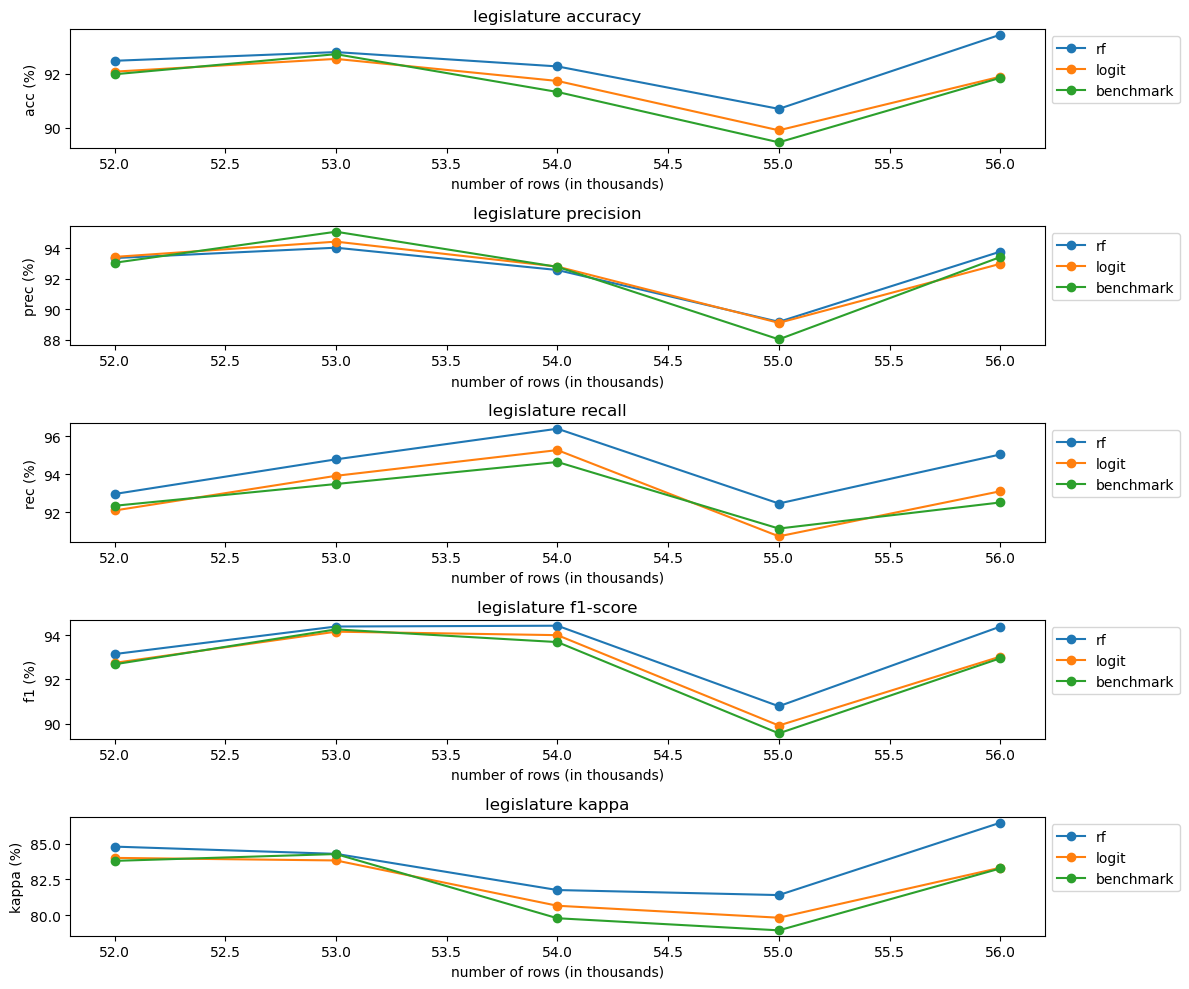

In [174]:
fig, axs = plt.subplots(nrows = len(metrics_cols),figsize=(12,10))    
for i,c in enumerate(metrics_cols):

    axs[i].set_title(f'legislature {dict_metrics_rename[c]}')
    axs[i].set_ylabel(f'{c} (%)')
    axs[i].set_xlabel('number of rows (in thousands)')
    # axs.set_xlim(-5, 1000) 
    # axs[i].set_ylim(-0.1,1.1) 

    for j,mod in enumerate(['rf', 'logit', 'benchmark']):
    # for j,mod in enumerate(models):
        df_f = df_metric_legis[df_metric_legis['model']==mod].sort_values('idLegislatura')
        axs[i].plot(df_f['idLegislatura'], df_f[c]*100, marker='o', label = f'{mod}')

    axs[i].legend(loc='best', bbox_to_anchor=(1, 1))

fig.tight_layout()        
plt.savefig(os.path.join(plots_path, f'metrics_overall_v1.png'))
plt.show()

 - Analyzis per voting

##### Voting Majority

In [175]:
y_test_agg_aux = y_test_agg[y_test_agg['legis_aux']!='overall']
y_test_agg_aux.to_csv(os.path.join(processed_path, 'forecast/predictions_filter.csv'), index=False)

In [176]:
df_vote_count = df_vot_meta.copy() 
df_vote_count.loc[df_vote_count[f'votosSim']>df_vote_count[f'votosNao'], f'maioria_sim_voto'] = 1
df_vote_count['maioria_sim_voto'] = df_vote_count['maioria_sim_voto'].fillna(0) 

# df_vote_count =y_test_agg_aux.groupby(['idVotacao'], as_index=False).size()    
model_cols = [x for x in y_test_agg_aux.columns if target in x and x!=target]
for c in model_cols:
    df_count = y_test_agg_aux.groupby(['idVotacao'], as_index=False)[c].value_counts()    
    df_count = df_count.pivot_table('count', ['idVotacao'], c)#.reset_index()
    df_count.columns = [f'{c}_{unidecode(x.lower())}' for x in df_count.columns]
    df_count = df_count.reset_index().fillna(0)

    c_ = c.split('_')[-1]
    df_count.loc[df_count[f'{c}_sim']>df_count[f'{c}_nao'], f'maioria_sim_{c_}'] = 1
    df_count[f'maioria_sim_{c_}'] = df_count[f'maioria_sim_{c_}'].fillna(0)
    df_vote_count = df_vote_count.merge(df_count, how='left', on = 'idVotacao')
    
    mask = ((df_vote_count['tipo_aprovacao'] == 'Maioria Simples') & (df_vote_count[f'{c}_sim'] >= round(df_vote_count['votosTotais']/2,0))) | \
           ((df_vote_count['tipo_aprovacao'] != 'Maioria Simples') & (df_vote_count[f'{c}_sim'] >= df_vote_count['votos_necessarios']))
        
    df_vote_count.loc[mask, f'aprovacao_{c_}'] = 1
    df_vote_count[f'aprovacao_{c_}'] = df_vote_count[f'aprovacao_{c_}'].fillna(0)    

In [177]:
df_vote_count = df_vote_count[~df_vote_count['voto_logit_sim'].isna()]
df_vote_count = df_vote_count.merge(df_votacoes[['data','idLegislatura', 'y', 'idVotacao']], how ='left', on = ['idVotacao']) 

In [178]:
# df_vote_count = df_vote_count[df_vote_count.flag_aprovacao==0 ]

In [179]:
major_cols = [x for x in df_vote_count if 'maioria' in x and target not in x]

In [180]:
df_vote_count_f = df_vote_count[['data','idLegislatura', 'y', 'idVotacao', 'maioria_sim_voto'] + major_cols]
for m in major_cols:
    m_ = m.split('_')[-1]
    df_vote_count_f.loc[df_vote_count_f['maioria_sim_voto'] == df_vote_count_f[m], f'flag_{m_}'] = 1
    df_vote_count_f[f'flag_{m_}'] = df_vote_count_f[f'flag_{m_}'].fillna(0)
    df_vote_count_f = df_vote_count_f.drop(m, axis=1)
df_vote_count_f = df_vote_count_f.drop('maioria_sim_voto',axis=1).rename(columns = {'y':'year'})
df_vote_count_f['month'] = pd.to_datetime(df_vote_count_f['data']).dt.strftime("%Y%m")

In [181]:
df_vote_count.to_csv(os.path.join(processed_path, f'votes/votes_count_v1.csv'), index=False)
df_vote_count_f.to_csv(os.path.join(processed_path, f'votes/votes_count_same_v1.csv'), index=False)

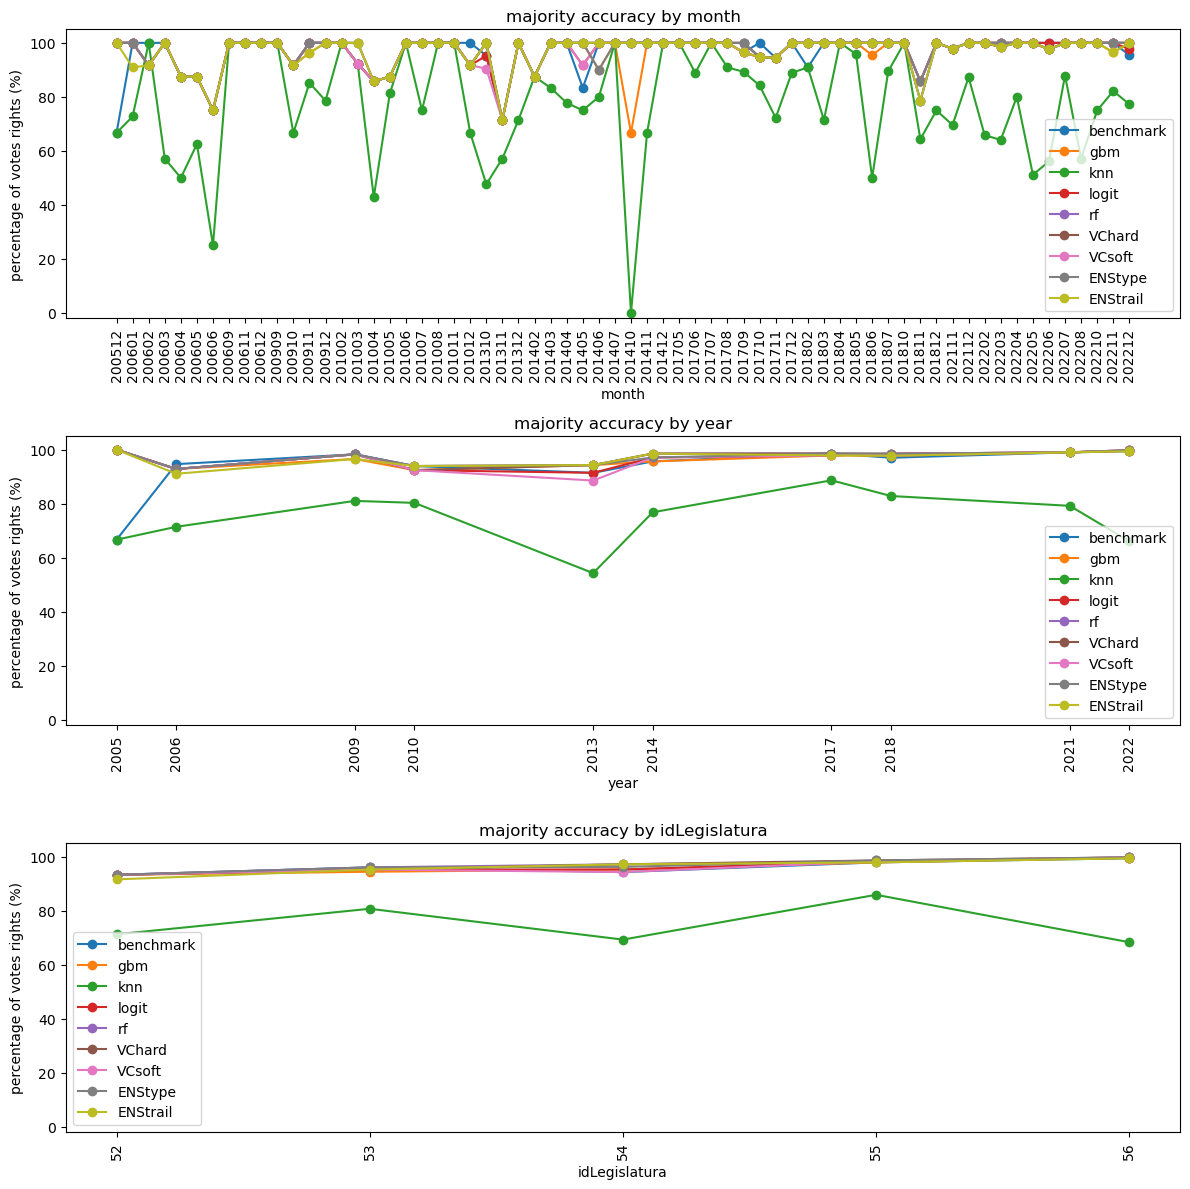

In [182]:
date_cols = ['month', 'year', 'idLegislatura']
fig, axs = plt.subplots(nrows = len(date_cols),figsize=(12,12))    
for i,date_ in enumerate(date_cols):

    df_vote_g = df_vote_count_f.groupby(date_, as_index=False).sum()        
    df_vote_g = df_vote_g.merge(df_vote_count_f.groupby(date_, as_index=False).size(), how='left', on =date_)

    subset_indices = np.arange(0, len(df_vote_g[date_]), 1)
    subset_labels = [str(label) for label in df_vote_g[date_][subset_indices]]

    axs[i].set_title(f'majority accuracy by {date_}')
    axs[i].set_xlabel(f'{date_}')
    axs[i].set_ylabel('percentage of votes rights (%)')
    # axs.set_xlim(-5, 1000) 
    axs[i].set_ylim(-2,105) 

    for c_ in [x for x in df_vote_g.columns if 'flag' in x]:
        df_vote_g[c_] = df_vote_g[c_]/df_vote_g['size']
        axs[i].plot(df_vote_g[date_], df_vote_g[c_]*100, marker='o', label = f"{c_.split('_')[-1]}")

    axs[i].legend(loc='best')
    axs[i].set_xticks(df_vote_g[date_][subset_indices])
    axs[i].set_xticklabels(subset_labels, rotation=90)

    # axs[i].xticks(df_vote_g[date_], df_vote_g[date_].to_list())
fig.tight_layout()        
# plt.savefig(os.path.join(plots_path, f'prob_skus_{abc}.png'))
plt.show()

##### Voting Approval

In [183]:
approval_cols = [x for x in df_vote_count if 'aprovacao' in x]
approval_cols = list(set(approval_cols) - set(['tipo_aprovacao', 'aprovacao', 'flag_aprovacao', 'aprovacao_calculo']))

In [184]:
df_vote_count_f = df_vote_count[['data','idLegislatura', 'y', 'idVotacao', 'aprovacao_calculo'] + approval_cols]
for m in approval_cols:
    m_ = m.split('_')[-1]
    df_vote_count_f.loc[df_vote_count_f['aprovacao_calculo'] == df_vote_count_f[m], f'flag_{m_}'] = 1
    df_vote_count_f[f'flag_{m_}'] = df_vote_count_f[f'flag_{m_}'].fillna(0)
    df_vote_count_f = df_vote_count_f.drop(m, axis=1)
df_vote_count_f = df_vote_count_f.drop('aprovacao_calculo',axis=1).rename(columns = {'y':'year'})
df_vote_count_f['month'] = pd.to_datetime(df_vote_count_f['data']).dt.strftime("%Y%m")

In [185]:
df_vote_count_f.to_csv(os.path.join(processed_path, f'votes/votes_count_approval_v1.csv'), index=False)

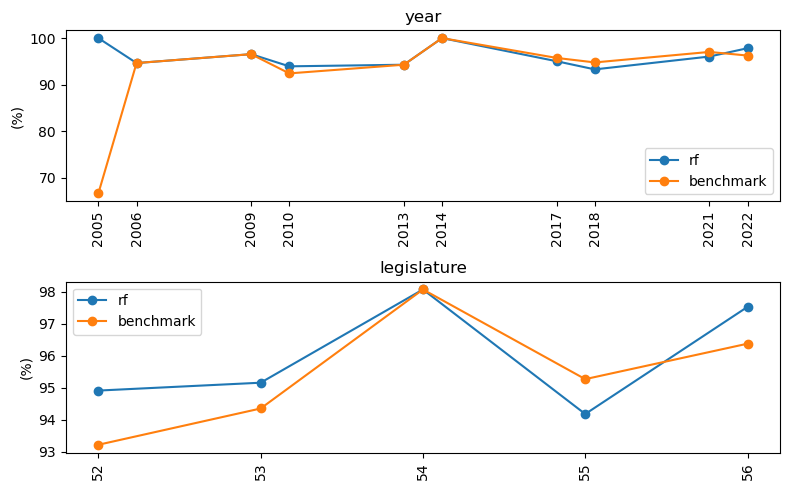

In [186]:
date_cols = ['year', 'idLegislatura']
fig, axs = plt.subplots(nrows = len(date_cols),figsize=(8,5))    
for i,date_ in enumerate(date_cols):

    df_vote_g = df_vote_count_f.groupby(date_, as_index=False).sum()        
    df_vote_g = df_vote_g.merge(df_vote_count_f.groupby(date_, as_index=False).size(), how='left', on =date_)

    subset_indices = np.arange(0, len(df_vote_g[date_]), 1)
    subset_labels = [str(label) for label in df_vote_g[date_][subset_indices]]

    axs[i].set_title(f"{date_.replace('idLegislatura', 'legislature')}")
    # axs[i].set_xlabel(f'{date_}')
    axs[i].set_ylabel('(%)')
    # axs.set_xlim(-5, 1000) 
    # axs[i].set_ylim(-2,105) 

    # for c_ in [x for x in df_vote_g.columns if 'flag' in x]:
    for c_ in ['flag_rf', 'flag_benchmark']:
        df_vote_g[c_] = df_vote_g[c_]/df_vote_g['size']
        axs[i].plot(df_vote_g[date_], df_vote_g[c_]*100, marker='o', label = f"{c_.split('_')[-1]}")

    axs[i].legend(loc='best')
    axs[i].set_xticks(df_vote_g[date_][subset_indices])
    axs[i].set_xticklabels(subset_labels, rotation=90)

    # axs[i].xticks(df_vote_g[date_], df_vote_g[date_].to_list())
fig.tight_layout()        
plt.savefig(os.path.join(plots_path, f'approval_accuracy_v1.png'))
plt.show()

##### Voting metrics over time

 - METRICS PLOTS (METRIC VS VOTE)

In [187]:
vote_id_list = y_test_agg_aux['idVotacao'].unique()
metrics_vote_dict = {x:{} for x in vote_id_list}
for vote_id in vote_id_list:

    y_test_f = y_test_agg_aux[y_test_agg_aux['idVotacao'] == vote_id].dropna(how='all', axis=1)      
    models = [x for x in y_test_f.columns if target in x and x!=target and "_" in x and 'necessarios' not in x]

    for model_name in models:

        pred_values = y_test_f[f'{model_name}'].to_list()
        real_values = y_test_f[target].to_list()

        eval_dict = evaluate_model(pred_values, real_values)
        metrics_vote_dict[vote_id][model_name] = eval_dict

In [188]:
df_metric_vote, df_cm_vote = unpack_dict(metrics_vote_dict.copy(), 'idVotacao')
df_metric_vote = df_metric_vote.merge(df_votacoes, how ='left', on = ['idVotacao'])
df_cm_vote = df_cm_vote.merge(df_votacoes, how ='left', on = ['idVotacao'])

In [189]:
df_metric_vote['data'] = pd.to_datetime(df_metric_vote['data'])
df_metric_vote['month'] = df_metric_vote['data'].dt.strftime("%Y%m")

In [190]:
df_metric_vote.to_csv(os.path.join(processed_path, f'metrics/metrics_vote_v1.csv'), index=False)
df_cm_vote.to_csv(os.path.join(processed_path, f'metrics/conf_matrix_vote_v1.csv'), index=False)

In [191]:
df_metric_vote['model'] = df_metric_vote['model'].str.split('_').str[-1]
models = df_metric_vote['model'].drop_duplicates().to_list()
models = [x for x in models if 'knn' not in x]

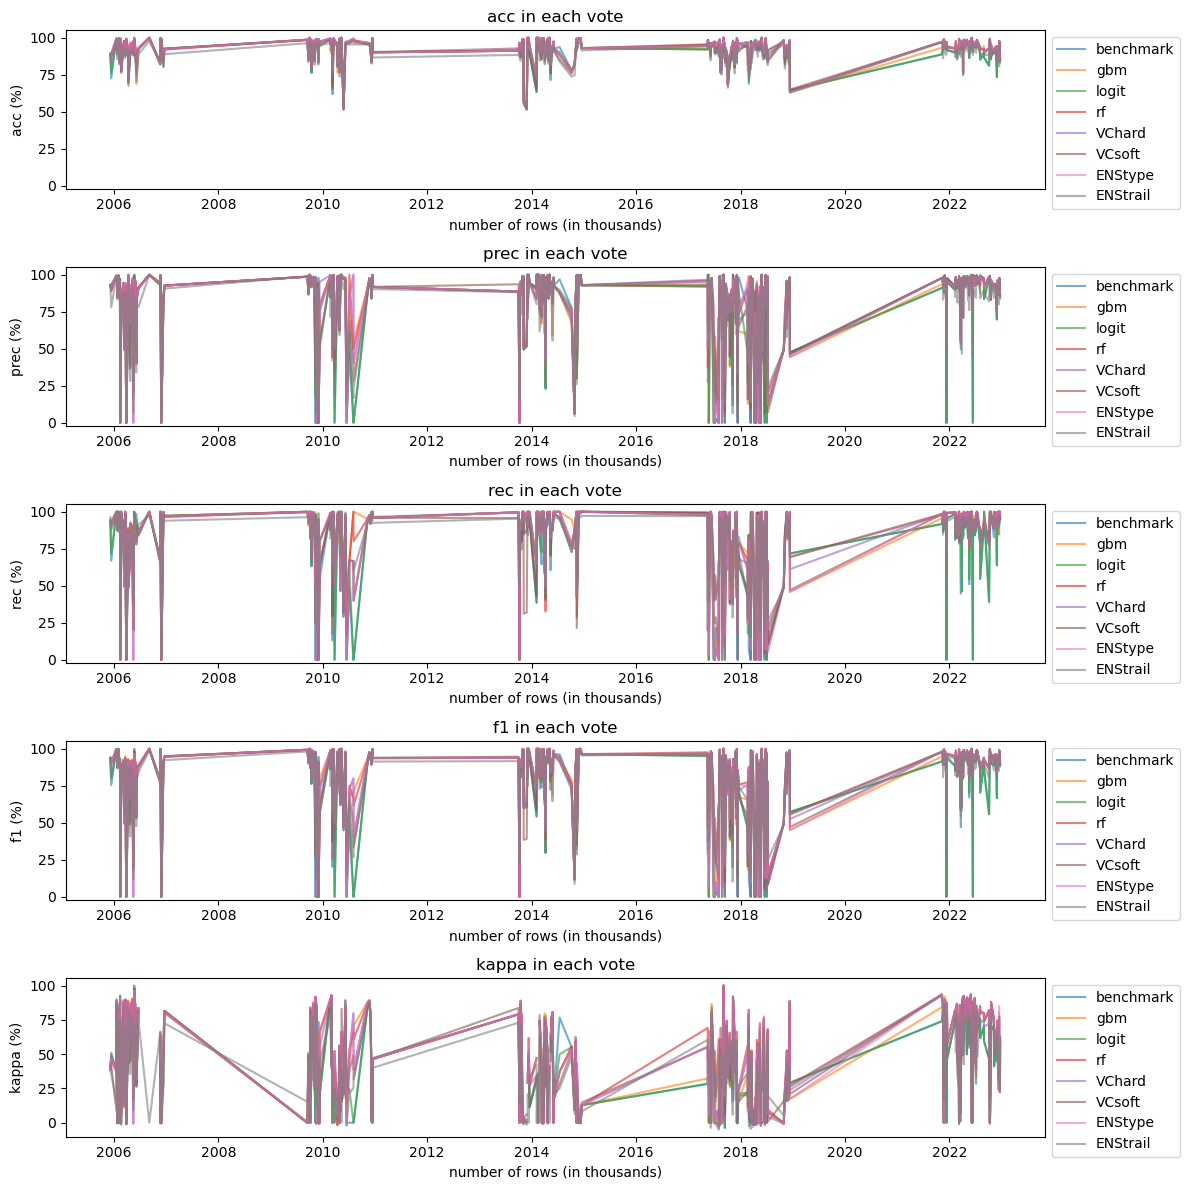

In [192]:
fig, axs = plt.subplots(nrows = len(metrics_cols),figsize=(12,12))    
for i,c in enumerate(metrics_cols):

    axs[i].set_title(f'{c} in each vote')
    axs[i].set_ylabel(f'{c} (%)')
    axs[i].set_xlabel('number of rows (in thousands)')
    # axs.set_xlim(-5, 1000) 
    if c!='kappa':
        axs[i].set_ylim(-2,105) 

    for j,mod in enumerate(models):
        df_f = df_metric_vote[df_metric_vote['model']==mod].sort_values('data')
        df_f = df_f.groupby("data", as_index=False).median()
        axs[i].plot(df_f['data'], df_f[c]*100, label = f'{mod}', alpha = .6)

    axs[i].legend(loc='best', bbox_to_anchor=(1, 1))

fig.tight_layout()        
# plt.savefig(os.path.join(plots_path, f'prob_skus_{abc}.png'))
plt.show()

In [259]:
plots_path

'D:\\Pedro\\Desktop\\Dropbox\\UnB\\Doc\\projects\\api_camara\\dados\\processed\\plots'

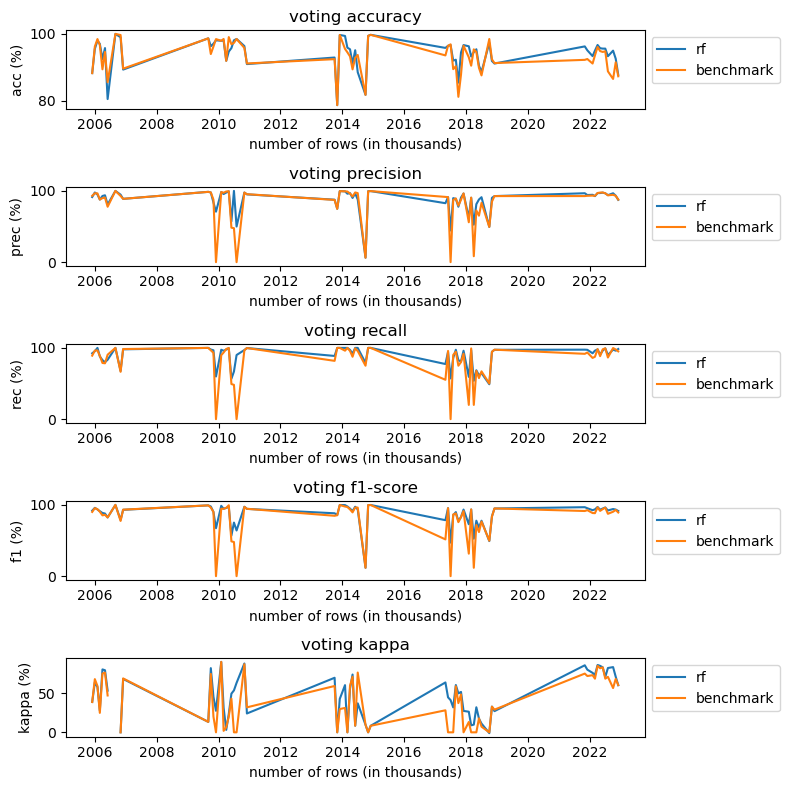

In [260]:
fig, axs = plt.subplots(nrows = len(metrics_cols),figsize=(8,8))    
for i,c in enumerate(metrics_cols):

    axs[i].set_title(f'voting {dict_metrics_rename[c]}')
    axs[i].set_ylabel(f'{c} (%)')
    axs[i].set_xlabel('number of rows (in thousands)')
    # axs.set_xlim(-5, 1000) 
    # if c!='kappa':
    #     axs[i].set_ylim(-2,105) 
        
    # for j,mod in enumerate(models):
    for j,mod in enumerate(['rf', 'benchmark']):
        df_f = df_metric_vote[df_metric_vote['model']==mod].sort_values('data')
        df_f = df_f.groupby("month", as_index=False).median()
        df_f['date'] = pd.to_datetime(df_f['month']+'01', format = "%Y%m%d")
        df_f = df_f.set_index('date')
        axs[i].plot(df_f[c]*100,label = f'{mod}')
        # axs[i].plot(df_f['month'], df_f[c]*100,'-o', label = f'{mod}')
        
    subset_indices = np.arange(0, len(df_f["month"]), 1)
    subset_labels = [pd.to_datetime(label+'01', format = "%Y%m%d") for label in df_f["month"][subset_indices]]
    
    axs[i].legend(loc='best', bbox_to_anchor=(1, 1))
    # axs[i].set_xticklabels(subset_labels, rotation=20)

    # axs[i].set_xlim([pd.to_datetime('2005-01-01'), pd.to_datetime('2023-01-01')])


fig.tight_layout()        
plt.savefig(os.path.join(plots_path, f'voting_id_month_v1.png'))
plt.show()

##### Type voting metrics

In [ ]:
y_test_agg_aux = y_test_agg[y_test_agg['legis_aux']!='overall']

In [ ]:
y_test_agg_aux = y_test_agg_aux.merge(df_vot_meta, how='left', on = ['idVotacao'])
vote_type_list = y_test_agg_aux['tipo_votacao'].unique()
metrics_vote_type_dict = {x:{} for x in vote_type_list}
for vote_type in vote_type_list:

    y_test_f = y_test_agg_aux[y_test_agg_aux['tipo_votacao'] == vote_type].dropna(how='all', axis=1)
    # if 'voto_VChard' in y_test_f.columns:
    #     y_test_f = y_test_f.dropna(subset = models)   
    models = [x for x in y_test_f.columns if target in x and x!=target and 'votos' not in x]

    for model_name in [x for x in models if 'ENS' not in x]:

        pred_values = y_test_f[f'{model_name}'].to_list()
        real_values = y_test_f[target].to_list()

        eval_dict = evaluate_model(pred_values, real_values)
        metrics_vote_type_dict[vote_type][model_name] = eval_dict

In [ ]:
df_metric_vote, df_cm_vote = unpack_dict(metrics_vote_type_dict.copy(), 'tipo_votacao')

In [ ]:
legis_list = sorted(df_metric_vote['tipo_votacao'].unique())
df_tp = pd.DataFrame()
for tp_vote in legis_list:
    print(f'calculating best models for vote type {tp_vote}')
    df_metrics_f = df_metric_vote[df_metric_vote['tipo_votacao'] == tp_vote][metrics_cols + ['model']].set_index('model')
    df_metrics_f = df_metrics_f[df_metrics_f.index!='voto_benchmark']
    for metric in metrics_cols:
        best_metric = df_metrics_f[metric].idxmax().replace('voto_', '')
        best_metric_value = df_metrics_f[metric].max()
        print(f' - best model for {metric} is: {best_metric} ({round(best_metric_value,2)})')
        
        df_ = pd.DataFrame({'type':tp_vote, 'metric': metric, 'model':best_metric, 'value':best_metric_value}, index= [0])
        df_tp = pd.concat([df_tp, df_])

In [ ]:
df_vot_size = df_vot_meta.groupby('tipo_votacao', as_index=False).size()
df_tp = df_tp.rename(columns = {'type':'tipo_votacao'}).merge(df_vot_size, how='left', on = 'tipo_votacao')

In [ ]:
df_tp[df_tp['metric'] == 'acc']#[['type', 'model']]

In [ ]:
df_tp.to_csv(os.path.join(processed_path, 'ensemble_vote_type_v1.csv'), index=False)

In [ ]:
df_metric_vote[df_metric_vote!='voto_knn'].groupby('tipo_votacao').mean().sort_values("acc")

In [ ]:
df_metric_vote.groupby('model').mean()

### V2 - Non-orientaded analyzis

In [ ]:
version = 2

In [ ]:
y_test_agg = pd.read_csv(os.path.join(processed_path, f'predictions_v{1}.csv'))

In [ ]:
betrail_cols = [x for x in df_votos.columns if 'ori' in x and ('sim' in x or 'nao' in x) and ('gov' in x or 'part' in x or 'bancada' in x)]

In [ ]:
mask  = ((df_votos['d_ori_part_nao'] == 1) & (df_votos['voto'] == 'Sim' )) | \
        ((df_votos['d_ori_part_sim'] == 1) & (df_votos['voto'] == 'Não' )) | \
        ((df_votos['d_ori_gov_nao'] == 1) & (df_votos['voto'] == 'Sim' ) & ((df_votos['d_part_presid'] == 'Sim' ) | (df_votos['d_block_presid'] == 'Sim' ))) | \
        ((df_votos['d_ori_gov_sim'] == 1) & (df_votos['voto'] == 'Não' ) & ((df_votos['d_part_presid'] == 'Sim' ) | (df_votos['d_block_presid'] == 'Sim' ))) | \
        ((df_votos['d_ori_bancada_nao'] == 1) & (df_votos['voto'] == 'Sim' )) | \
        ((df_votos['d_ori_bancada_sim'] == 1) & (df_votos['voto'] == 'Não' ))

In [ ]:
df_votos_betrail = df_votos[mask][id_cols + betrail_cols].merge(y_test_agg,how='left', on = id_cols).dropna()

In [ ]:
pct_betrail_cols = [x for x in df_votos if 'traiu' in x]
df_betrail = df_votos[mask][id_cols + pct_betrail_cols]
df_not_betrail = df_votos[~mask][id_cols +pct_betrail_cols]

In [ ]:
df_betrail['pct_traiu_ori_part'].describe()

In [ ]:
df_not_betrail['pct_traiu_ori_part'].describe()

In [ ]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (15,4))    

axs[0].hist(df_betrail['pct_traiu_ori_part'], bins = 100)
axs[1].hist(df_not_betrail['pct_traiu_ori_part'], bins = 100)
axs[2].hist(df_votos['pct_traiu_ori_part'], bins = 100)

fig.tight_layout()        
# plt.savefig(os.path.join(plots_path, f'prob_skus_{abc}.png'))
plt.show()

In [ ]:
legis_list = df_votos_betrail['idLegislatura'].unique()
metrics_legis_dict2 = {x:{} for x in legis_list}
models = ['logit', 'knn', 'benchmark', 'gbm','rf']

In [ ]:
for legis_ in legis_list:
    df_f = df_votos_betrail[df_votos_betrail['idLegislatura'] == legis_]
    real_values = df_f[target].to_list()
    for model_name in models:
        pred_values = df_f[f'voto_{model_name}'].to_list()
        eval_dict = evaluate_model(pred_values, real_values)
        metrics_legis_dict2[legis_][model_name] = eval_dict

In [ ]:
df_metric_legis, df_cm_legis = unpack_dict(metrics_legis_dict2, 'idLegislatura')

#### Eval

##### Metrics Overall

In [ ]:
legis_list = sorted(df_metric_legis['idLegislatura'].unique())
for legis_ in legis_list:
    print(f'calculating best models for legis {legis_}')
    df_metrics_f = df_metric_legis[df_metric_legis['idLegislatura'] == legis_][metrics_cols + ['model']].set_index('model')
    for metric in metrics_cols:
        best_metric = df_metrics_f[metric].idxmax()
        print(f' - best model for {metric} is: {best_metric}')

In [ ]:
fig, axs = plt.subplots(nrows = len(metrics_cols),figsize=(12,12))    
for i,c in enumerate(metrics_cols):

    axs[i].set_title(f'legislature {dict_metrics_rename[c]}')
    axs[i].set_ylabel(f'{c} (%)')
    axs[i].set_xlabel('number of rows (in thousands)')
    # axs.set_xlim(-5, 1000) 
    # axs[i].set_ylim(-0.1,1.1) 

    for j,mod in enumerate(models):
        df_f = df_metric_legis[df_metric_legis['model']==mod].sort_values('idLegislatura')
        axs[i].plot(df_f['idLegislatura'], df_f[c]*100, marker='o', label = f'{mod}')

    axs[i].legend(loc='best')

fig.tight_layout()        
# plt.savefig(os.path.join(plots_path, f'prob_skus_{abc}.png'))
plt.show()

##### Voting Majority

In [ ]:
df_vote_count = df_votos_betrail.groupby(['idVotacao'], as_index=False).size()    
model_cols = [x for x in df_votos_betrail.columns if target in x]
for c in model_cols:
    c_ = c.split('_')[-1]

    df_count = df_votos_betrail.groupby(['idVotacao'], as_index=False)[c].value_counts()    
    df_count = df_count.pivot_table('count', ['idVotacao'], c)#.reset_index()
    df_count.columns = [f'{c}_{unidecode(x.lower())}' for x in df_count.columns]
    df_count = df_count.reset_index().fillna(0)

    df_count.loc[df_count[f'{c}_sim']>df_count[f'{c}_nao'], f'maioria_sim_{c_}'] = 1
    df_count[f'maioria_sim_{c_}'] = df_count[f'maioria_sim_{c_}'].fillna(0)
    df_vote_count = df_vote_count.merge(df_count, how='left', on = 'idVotacao')

In [ ]:
df_vote_count = df_vote_count.merge(df_votacoes, how ='left', on = ['idVotacao']) 

In [ ]:
major_cols = [x for x in df_vote_count if 'maioria' in x and target not in x]

In [ ]:
df_vote_count_f = df_vote_count[['data','idLegislatura', 'y', 'idVotacao', 'maioria_sim_voto'] + major_cols]
for m in major_cols:
    m_ = m.split('_')[-1]
    df_vote_count_f.loc[df_vote_count_f['maioria_sim_voto'] == df_vote_count_f[m], f'flag_{m_}'] = 1
    df_vote_count_f[f'flag_{m_}'] = df_vote_count_f[f'flag_{m_}'].fillna(0)
    df_vote_count_f = df_vote_count_f.drop(m, axis=1)
df_vote_count_f = df_vote_count_f.drop('maioria_sim_voto',axis=1).rename(columns = {'y':'year'})
df_vote_count_f['month'] = pd.to_datetime(df_vote_count_f['data']).dt.strftime("%Y%m")

In [ ]:
df_vote_count.to_csv(os.path.join(processed_path, f'votes_count_v2.csv'), index=False)
df_vote_count_f.to_csv(os.path.join(processed_path, f'votes_count_same_v2.csv'), index=False)

In [ ]:
date_cols = ['month', 'year', 'idLegislatura']
fig, axs = plt.subplots(nrows = len(date_cols),figsize=(12,12))    
for i,date_ in enumerate(date_cols):

    df_vote_g = df_vote_count_f.groupby(date_, as_index=False).sum()        
    df_vote_g = df_vote_g.merge(df_vote_count_f.groupby(date_, as_index=False).size(), how='left', on =date_)

    subset_indices = np.arange(0, len(df_vote_g[date_]), 1)
    subset_labels = [str(label) for label in df_vote_g[date_][subset_indices]]

    axs[i].set_title(f'majority accuracy by {date_}')
    axs[i].set_xlabel(f'{date_}')
    axs[i].set_ylabel('percentage of votes rights (%)')
    # axs.set_xlim(-5, 1000) 
    # axs[i].set_ylim(-0.1,1.1) 

    for c_ in [x for x in df_vote_g.columns if 'flag' in x]:
        df_vote_g[c_] = df_vote_g[c_]/df_vote_g['size']
        axs[i].plot(df_vote_g[date_], df_vote_g[c_]*100, marker='o', label = f"{c_.split('_')[-1]}")

    axs[i].legend(loc='best')
    axs[i].set_xticks(df_vote_g[date_][subset_indices])
    axs[i].set_xticklabels(subset_labels, rotation=90)

    # axs[i].xticks(df_vote_g[date_], df_vote_g[date_].to_list())
fig.tight_layout()        
# plt.savefig(os.path.join(plots_path, f'prob_skus_{abc}.png'))
plt.show()

##### Voting metrics over time

In [ ]:
vote_id_list = df_votos_betrail['idVotacao'].unique()
metrics_vote_dict = {x:{} for x in vote_id_list}
for vote_id in vote_id_list:

    y_test_f = df_votos_betrail[df_votos_betrail['idVotacao'] == vote_id].dropna(how='all', axis=1)      
    models = [x for x in y_test_f.columns if target in x and x!=target]

    for model_name in models:

        pred_values = y_test_f[f'{model_name}'].to_list()
        real_values = y_test_f[target].to_list()

        eval_dict = evaluate_model(pred_values, real_values)
        metrics_vote_dict[vote_id][model_name] = eval_dict

In [ ]:
df_metric_vote, df_cm_vote = unpack_dict(metrics_vote_dict.copy(), 'idVotacao')
df_metric_vote = df_metric_vote.merge(df_votacoes, how ='left', on = ['idVotacao'])
df_cm_vote = df_cm_vote.merge(df_votacoes, how ='left', on = ['idVotacao'])

In [ ]:
df_metric_vote['data'] = pd.to_datetime(df_metric_vote['data'])
df_metric_vote['month'] = df_metric_vote['data'].dt.strftime("%Y%m")

In [ ]:
df_metric_vote.to_csv(os.path.join(processed_path, f'metrics_vote_v{version}.csv'), index=False)
df_cm_vote.to_csv(os.path.join(processed_path, f'conf_matrix_vote_v{version}.csv'), index=False)

In [ ]:
df_metric_vote['model'] = df_metric_vote['model'].str.split('_').str[-1]
models = df_metric_vote['model'].drop_duplicates().to_list()
models = [x for x in models]

 - METRICS PLOTS (METRIC VS VOTE)

In [ ]:
fig, axs = plt.subplots(nrows = len(metrics_cols),figsize=(12,12))    
for i,c in enumerate(metrics_cols):

    axs[i].set_title(f'voting {dict_metrics_rename[c]}')
    axs[i].set_ylabel(f'{c} (%)')
    axs[i].set_xlabel('number of rows (in thousands)')
    # axs.set_xlim(-5, 1000) 
    axs[i].set_ylim(-2,105) 

    for j,mod in enumerate(models):
        df_f = df_metric_vote[df_metric_vote['model']==mod].sort_values('data')
        df_f = df_f.groupby("data", as_index=False).median()
        axs[i].plot(df_f['data'], df_f[c]*100, label = f'{mod}', alpha = .6)

    axs[i].legend(loc='best', bbox_to_anchor=(1, 1))

fig.tight_layout()        
# plt.savefig(os.path.join(plots_path, f'prob_skus_{abc}.png'))
plt.show()

In [ ]:
fig, axs = plt.subplots(nrows = len(metrics_cols),figsize=(15,12))    
for i,c in enumerate(metrics_cols):

    axs[i].set_title(f'voting {dict_metrics_rename[c]}')
    axs[i].set_ylabel(f'{c} (%)')
    axs[i].set_xlabel('number of rows (in thousands)')
    # axs.set_xlim(-5, 1000)
    if c!='kappa':
        axs[i].set_ylim(-2,105) 

    for j,mod in enumerate(models):
        df_f = df_metric_vote[df_metric_vote['model']==mod].sort_values('data')
        df_f = df_f.groupby("month", as_index=False).median()
        axs[i].plot(df_f['month'], df_f[c]*100, label = f'{mod}', alpha = .6)

    subset_indices = np.arange(0, len(df_f["month"]), 1)
    subset_labels = [str(label) for label in df_f["month"][subset_indices]]

    axs[i].legend(loc='best', bbox_to_anchor=(1, 1))
    axs[i].set_xticklabels(subset_labels, rotation=60)

fig.tight_layout()        
# plt.savefig(os.path.join(plots_path, f'prob_skus_{abc}.png'))
plt.show()

In [ ]:
legis_list = sorted(df_metric_legis['idLegislatura'].unique())
for legis_ in legis_list:
    print(f'calculating best models for legis {legis_}')
    df_metrics_f = df_metric_legis[df_metric_legis['idLegislatura'] == legis_][metrics_cols + ['model']].set_index('model')
    for metric in metrics_cols:
        best_metric = df_metrics_f[metric].idxmax()
        print(f' - best model for {metric} is: {best_metric}')

##### Type voting metrics

In [ ]:
y_test_agg_aux = df_votos_betrail.copy()

In [ ]:
y_test_agg_aux = y_test_agg_aux.merge(df_vot_meta, how='left', on = ['idVotacao'])
vote_type_list = y_test_agg_aux['tipo_votacao'].unique()
metrics_vote_type_dict = {x:{} for x in vote_type_list}
for vote_type in vote_type_list:

    y_test_f = y_test_agg_aux[y_test_agg_aux['tipo_votacao'] == vote_type].dropna(how='all', axis=1)      
    models = [x for x in y_test_f.columns if target in x and x!=target and 'votos' not in x]

    for model_name in models:

        pred_values = y_test_f[f'{model_name}'].to_list()
        real_values = y_test_f[target].to_list()

        eval_dict = evaluate_model(pred_values, real_values)
        metrics_vote_type_dict[vote_type][model_name] = eval_dict

In [ ]:
df_metric_vote, df_cm_vote = unpack_dict(metrics_vote_type_dict.copy(), 'tipo_votacao')

In [ ]:
legis_list = sorted(df_metric_vote['tipo_votacao'].unique())
for tp_vote in legis_list:
    print(f'calculating best models for vote type {tp_vote}')
    df_metrics_f = df_metric_vote[df_metric_vote['tipo_votacao'] == tp_vote][metrics_cols + ['model']].set_index('model')
    for metric in metrics_cols:
        best_metric = df_metrics_f[metric].idxmax()
        print(f' - best model for {metric} is: {best_metric} ({round(df_metrics_f[metric].max(),2)})')

### V3 - Without orientation features

#### Open results

In [44]:
version = 3
show_shap = False
show_importance = True

In [48]:
legis_list = list({x.split('_')[-1].split('.')[0] for x in model_files})
legis_list = [x for x in legis_list if x!='old' and x!='v2' and x!='overall']

In [49]:
metrics_legis_dict = {x:{} for x in legis_list}
importance_dict = {x:{} for x in legis_list}
g_importance_dict = {x:{} for x in legis_list}
g_importance_dict2 = {x:{} for x in legis_list}
hyperparams_dict = {x:{} for x in legis_list}
y_test_agg = pd.DataFrame()

In [218]:
models

['model_gbm_56_v2.sav',
 'model_knn_56_v2.sav',
 'model_logit_56_v2.sav',
 'model_rf_56_v2.sav']

In [223]:

df_votos_f = df_votos[df_votos['idLegislatura'] == int(legis)]

df_std = df_votos_f.select_dtypes('number').std().reset_index()
df_std.columns = ['var', 'std']

df_std = df_std[~ df_std['var'].isin(id_cols + [target])]
cols_to_drop = df_std[df_std['std'] == 0]['var'].to_list()

df_votos_f = df_votos_f.drop(cols_to_drop,axis=1)

cols_ori = [x for x in df_votos_f.columns if 'd_ori' in x]
df_votos_f = df_votos_f.drop(cols_ori,axis=1)   

X = df_votos_f.set_index(id_cols).drop(target,axis=1)
y = df_votos_f.set_index(id_cols)[target]

X_train, X_test, y_train, y_test = model.split_data(df_votos_f, X, y, train_size, id_cols, target, rand)

f = 'model_logit_52_v2.sav'
y_test['legis_aux'] = legis

print(f'opening {f}...')
model_fit = pickle.load(open(os.path.join(models_path, f), 'rb'))
if len(f.split('_'))<5:
    model_name = f.split('_')[1]    
else:
    model_name =  '_'.join(f.split('_')[1:3])        
cols = X_test.columns.to_list()
df_meta_ = df_meta[df_meta['var'].isin(cols)][['var', 'grupo','subgrupo']].drop_duplicates() 

dict_vars_ = {x:[x] for x in cols}



opening model_logit_52_v2.sav...


In [224]:
n_rep = 2

In [1]:
dict_importance_f = groupped_perm_importance(model_fit, X_test, y_test[target],dict_vars_, n_rep, rand, n_jobs)

In [51]:
# Open models e calculate metrics
for legis in sorted(legis_list):

    models = [x for x in model_files if str(int(legis)) in x and 'v2' in x]
    print(models)
    metrics_legis_dict[legis] = {}
    importance_dict[legis] = {}
    hyperparams_dict[legis] = {}

    if legis == 'overall':
        df_votos_f = df_votos.copy()
    else:
        df_votos_f = df_votos[df_votos['idLegislatura'] == int(legis)]

    df_std = df_votos_f.select_dtypes('number').std().reset_index()
    df_std.columns = ['var', 'std']

    df_std = df_std[~ df_std['var'].isin(id_cols + [target])]
    cols_to_drop = df_std[df_std['std'] == 0]['var'].to_list()

    df_votos_f = df_votos_f.drop(cols_to_drop,axis=1)

    cols_ori = [x for x in df_votos_f.columns if 'd_ori' in x]
    df_votos_f = df_votos_f.drop(cols_ori,axis=1)   
    
    X = df_votos_f.set_index(id_cols).drop(target,axis=1)
    y = df_votos_f.set_index(id_cols)[target]

    X_train, X_test, y_train, y_test = model.split_data(df_votos_f, X, y, train_size, id_cols, target, rand)
    # print(legis, X_train.shape, X_test.shape)

    for f in models:
        y_test['legis_aux'] = legis

        print(f'opening {f}...')
        model_fit = pickle.load(open(os.path.join(models_path, f), 'rb'))
        if len(f.split('_'))<5:
            model_name = f.split('_')[1]    
        else:
            model_name =  '_'.join(f.split('_')[1:3])        
        
        try:
            hyperparams_dict[legis][model_name] = model_fit.best_params_
        except:
            pass
        pred_values = [x for x in model_fit.predict(X_test)]

        y_test[f'{target}_{model_name}'] =  pred_values            
        real_values = y_test[target].to_list()

        eval_dict = evaluate_model(pred_values, real_values)
        metrics_legis_dict[legis][model_name] = eval_dict

        if show_shap:
            if model_name in ['logit', 'gbm']:
                plot_shap(model_fit, X_train, plots_path, model_name, legis, version = 3)
            else:
                print(f'{model_name} {legis} could not use SHAP')

        if show_importance and 'VC' not in model_name and 'knn' not in model_name and 'rf' not in model_name and 'bench' not in model_name:
            n_rep = 30
            cols = X_test.columns.to_list()
            df_meta_ = df_meta[df_meta['var'].isin(cols)][['var', 'grupo','subgrupo']].drop_duplicates() 

            dict_vars_ = {x:[x] for x in cols}
            dict_group_ = {x:df_meta_[df_meta_['grupo'] ==x]['var'].to_list() for x in df_meta_['grupo'].unique()}
            dict_subgroup_ = {x:df_meta_[df_meta_['subgrupo'] ==x]['var'].to_list() for x in df_meta_['subgrupo'].unique()}
            
            try:
                # dict_importance_f = perm_importance(model_fit, X_test, y_test[target], n_rep, rand, n_jobs)
                dict_importance_f = groupped_perm_importance(model_fit, X_test, y_test[target],dict_vars_, n_rep, rand, n_jobs)
                dict_g_importance_f = groupped_perm_importance(model_fit, X_test, y_test[target],dict_group_, n_rep, rand, n_jobs)
                dict_g_importance_f_ = groupped_perm_importance(model_fit, X_test, y_test[target],dict_subgroup_, n_rep, rand, n_jobs)
            except:
                n_rep = 10
                try:
                    # dict_importance_f = perm_importance(model_fit, X_test, y_test[target], n_rep, rand, n_jobs)
                    dict_importance_f = groupped_perm_importance(model_fit, X_test, y_test[target],dict_vars_, n_rep, rand, n_jobs)
                    dict_g_importance_f = groupped_perm_importance(model_fit, X_test, y_test[target],dict_group_, n_rep, rand, n_jobs)
                    dict_g_importance_f_ = groupped_perm_importance(model_fit, X_test, y_test[target],dict_subgroup_, n_rep, rand, n_jobs)
                except:
                    print(f'{model_name} {legis} could not use feat import')

        # elif model_name == 'benchmark':
        #     feature_names = X_test_bench.columns.to_list()
        #     idxs = []
        #     columns = [x.replace('d_ori_','') for x in feature_names if len(x.split('_')) == 3]
        #     dict_importance_f = perm_importance(model_fit, X_test_bench, y_test[target], n_rep, rand, n_jobs)
        #     dict_g_importance_f = groupped_perm_importance(model_fit, X_test_bench, y_test[target],idxs, n_rep, rand, n_jobs)

            importance_dict[legis][model_name] = dict_importance_f
            g_importance_dict[legis][model_name] = dict_g_importance_f
            g_importance_dict2[legis][model_name] = dict_g_importance_f_
            
            for k,v in dict_importance_f.items():
                v.to_csv(os.path.join(processed_path,f'features/raw/permutation_importance_{model_name}_{k}_{legis}_v3.csv'), index=False)
            for k,v in dict_g_importance_f.items():
                v.to_csv(os.path.join(processed_path,f'features/raw/groupped_permutation_importance_{model_name}_{k}_{legis}_v3.csv'), index=False)
            for k,v in dict_g_importance_f_.items():
                v.to_csv(os.path.join(processed_path,f'features/raw/subgroupped_permutation_importance_{model_name}_{k}_{legis}_v3.csv'), index=False)
    y_test = y_test.reset_index()
    y_test_agg = pd.concat([y_test_agg,y_test])

['model_gbm_52_v2.sav', 'model_knn_52_v2.sav', 'model_logit_52_v2.sav', 'model_rf_52_v2.sav', 'model_VChard_52_v2.sav', 'model_VCsoft_52_v2.sav']
opening model_gbm_52_v2.sav...
opening model_knn_52_v2.sav...
opening model_logit_52_v2.sav...
opening model_rf_52_v2.sav...
opening model_VChard_52_v2.sav...
opening model_VCsoft_52_v2.sav...
['model_gbm_53_v2.sav', 'model_knn_53_v2.sav', 'model_logit_53_v2.sav', 'model_rf_53_v2.sav', 'model_VChard_53_v2.sav', 'model_VCsoft_53_v2.sav']
opening model_gbm_53_v2.sav...
opening model_knn_53_v2.sav...
opening model_logit_53_v2.sav...
opening model_rf_53_v2.sav...
opening model_VChard_53_v2.sav...
opening model_VCsoft_53_v2.sav...
['model_gbm_54_v2.sav', 'model_knn_54_v2.sav', 'model_logit_54_v2.sav', 'model_rf_54_v2.sav', 'model_VChard_54_v2.sav', 'model_VCsoft_54_v2.sav']
opening model_gbm_54_v2.sav...
opening model_knn_54_v2.sav...
opening model_logit_54_v2.sav...
opening model_rf_54_v2.sav...
opening model_VChard_54_v2.sav...
opening model_VCs

In [ ]:
with open(os.path.join(processed_path,f'hyperparams/hyperparams_v{3}.json'), 'w', encoding='latin1') as f:
    json.dump(hyperparams_dict, f)

In [67]:
dict_import = {}
for k in ['full', 'mean']:    
    df_import = pd.DataFrame()    
    for legis in importance_dict.keys():
        for model_name, dict_importance_f in importance_dict[legis].items():                
            df_ = dict_importance_f[k].copy()                
            df_['legis'] = legis
            df_['model_name'] = model_name                
            df_import = pd.concat([df_import,df_])                
    dict_import[k] = df_import  
    df_import.to_csv(os.path.join(processed_path, f'perm_importance_{k}_v{version}.csv'), index=False)

In [65]:
dict_import = {}
for k in ['full', 'mean']:    
    df_import = pd.DataFrame()    
    for legis in g_importance_dict.keys():
        for model_name, dict_importance_f in g_importance_dict[legis].items():                
            df_ = dict_importance_f[k].copy()                
            df_['legis'] = legis
            df_['model_name'] = model_name                
            df_import = pd.concat([df_import,df_])                
    dict_import[k] = df_import  
    df_import.to_csv(os.path.join(processed_path, f'g_perm_importance_{k}_v{version}.csv'), index=False)

In [66]:
dict_import = {}
for k in ['full', 'mean']:    
    df_import = pd.DataFrame()    
    for legis in g_importance_dict2.keys():
        for model_name, dict_importance_f in g_importance_dict2[legis].items():                
            df_ = dict_importance_f[k].copy()                
            df_['legis'] = legis
            df_['model_name'] = model_name                
            df_import = pd.concat([df_import,df_])                
    dict_import[k] = df_import  
    df_import.to_csv(os.path.join(processed_path, f'sb_perm_importance_{k}_v{version}.csv'), index=False)

In [ ]:
# with open(os.path.join(processed_path,'perm_importance.json'), 'w', encoding='latin1') as f:
#     json.dump(dict_import, f)

In [ ]:
df_metric_legis, df_cm_legis = unpack_dict(metrics_legis_dict, 'idLegislatura')
df_metric_legis = df_metric_legis.merge(df_time_, how='left', on = ['idLegislatura', 'model'])

In [ ]:
models = df_metric_legis['model'].drop_duplicates().to_list()
# models = [x for x in models if 'svm' not in x and 'knn' not in x]

 - Fill Voting Classifier model with RF

In [ ]:
y_test_agg = y_test_agg.merge(df_vot_meta[['idVotacao', 'tipo_votacao']], how='left', on = ['idVotacao'])

In [ ]:
for c in ['voto_VChard', 'voto_VCsoft']:
    y_test_agg.loc[y_test_agg[c].isna(),c] = y_test_agg['voto_gbm']

In [ ]:
df_ensemble_tp.head(2)

 - Ensemble model 1: Choose best model by type of vote

In [ ]:
metric_ensemble = 'acc'

In [ ]:
df_ensemble_tp = pd.read_csv(os.path.join(processed_path, 'ensemble/ensemble_vote_type.csv'))
df_ensemble_tp = df_ensemble_tp[df_ensemble_tp.metric == metric_ensemble][['type','model']]
df_ensemble_tp.columns = ['tipo_votacao', 'model']

In [ ]:
y_test_agg = y_test_agg.merge(df_ensemble_tp, how='left', on = 'tipo_votacao')

In [ ]:
for m in [x for x in models if 'bench' not in x]:
    y_test_agg.loc[y_test_agg['model'] == m, 'voto_ENStype'] = y_test_agg[f'voto_{m}']

In [ ]:
y_test_agg = y_test_agg.drop(['tipo_votacao','model'], axis=1)

 - Ensemble 2: RF for betrail rate < 10 and GBM for > 10

In [ ]:
df_f = df_votos[df_votos['pct_traiu_ori_part']>0.1][id_cols]
df_f['model'] = 'knn'

In [ ]:
y_test_agg = y_test_agg.merge(df_f, how='left', on = id_cols)
y_test_agg['model'] = y_test_agg['model'].fillna('rf') 

In [ ]:
for m in ['rf', 'knn']:
    y_test_agg.loc[y_test_agg['model'] == m, 'voto_ENStrail'] = y_test_agg[f'voto_{m}']

In [ ]:
y_test_agg = y_test_agg.drop(['model'], axis=1)

In [ ]:
legis_list = sorted(y_test_agg['idLegislatura'].unique())
metrics_legis_dict_ = {x:{} for x in legis_list}
models_ = [x for x in y_test_agg.columns if  target in x and x!=target]

for legis in legis_list:
    
    df_ = y_test_agg[y_test_agg['idLegislatura'] == legis]
    for model_name in models_:
        pred_values = df_[model_name]
        real_values = df_[target].to_list()

        eval_dict = evaluate_model(pred_values, real_values)
        metrics_legis_dict_[legis][model_name] = eval_dict

In [ ]:
df_metric_legis, df_cm_legis = unpack_dict(metrics_legis_dict_, 'idLegislatura')
df_metric_legis['idLegislatura'] = df_metric_legis['idLegislatura'].astype(int).astype(str)
df_metric_legis['model'] = df_metric_legis['model'].str.split('_').str[-1]
df_metric_legis = df_metric_legis.merge(df_time_, how='left', on = ['idLegislatura', 'model'])

In [ ]:
y_test_agg.to_csv(os.path.join(processed_path, f'forecast/predictions_v3.csv'), index=False)
df_metric_legis.to_csv(os.path.join(processed_path, f'metrics/metrics_legis_v3.csv'), index=False)
df_cm_legis.to_csv(os.path.join(processed_path, f'metrics/conf_matrix_legis_v3.csv'), index=False)

#### Eval

In [ ]:
y_test_agg = pd.read_csv(os.path.join(processed_path, f'forecast/predictions_v3.csv'))#.drop_duplicates()
df_metric_legis = pd.read_csv(os.path.join(processed_path, f'metrics/metrics_legis_v3.csv')).drop_duplicates()
df_cm_legis = pd.read_csv(os.path.join(processed_path, f'metrics/conf_matrix_legis_v3.csv')).drop_duplicates()

##### Metrics overall

In [ ]:
df_metric_legis.columns

In [ ]:
# df_metric_legis.sort_values(['idLegislatura', 'acc'], ascending = [True, False])[['idLegislatura', 'model', 'acc']]
# df_metric_legis[df_metric_legis['model'].isin(['rf', 'ENStype', 'benchmark'])].sort_values(['idLegislatura', 'acc'], ascending = [True, False])[['idLegislatura', 'model', 'acc']]
df_metric_legis.groupby('model')['rec'].describe().sort_values('mean')

In [ ]:
legis_list = sorted(df_metric_legis['idLegislatura'].unique())
for legis_ in legis_list:
    print(f'calculating best models for legis {legis_}')
    df_metrics_f = df_metric_legis[df_metric_legis['idLegislatura'] == legis_][metrics_cols + ['model']].set_index('model')
    for metric in metrics_cols:
        best_metric = df_metrics_f[metric].idxmax()
        print(f' - best model for {metric} is: {best_metric} ({round(df_metrics_f[metric].max(),2)})')

In [ ]:
fig, axs = plt.subplots(nrows = len(metrics_cols),figsize=(12,10))    
for i,c in enumerate(metrics_cols):

    axs[i].set_title(f'legislature {dict_metrics_rename[c]}')
    axs[i].set_ylabel(f'{c} (%)')
    # axs[i].set_xlabel('number of rows (in thousands)')
    # axs.set_xlim(-5, 1000)
    # if c != 'kappa':
        # axs[i].set_ylim(-2,105) 

    # for j,mod in enumerate(models):
    for j,mod in enumerate(['gbm', 'rf','knn']):
        
        df_f = df_metric_legis[df_metric_legis['model']==mod.split('_')[-1]].sort_values('idLegislatura')
        axs[i].plot(df_f['idLegislatura'], df_f[c]*100, marker='o', label = f'{mod}')

    # axs[i].legend(loc='best')
    axs[i].legend(bbox_to_anchor=(1, 1))
    # axs[i].grid()


fig.tight_layout()        
plt.savefig(os.path.join(plots_path, f'metrics_overall_v3.png'))
plt.show()

##### Voting majority

In [ ]:
y_test_agg_aux = y_test_agg[y_test_agg['legis_aux']!='overall']
# y_test_agg_aux = y_test_agg_aux.merge(df_vot_meta, how='left', on ='idVotacao')
# y_test_agg_aux.to_csv(os.path.join(processed_path, 'predictions_filter.csv'), index=False)

In [ ]:
df_vote_count = df_vot_meta.copy() 
df_vote_count.loc[df_vote_count[f'votosSim']>df_vote_count[f'votosNao'], f'maioria_sim_voto'] = 1
df_vote_count['maioria_sim_voto'] = df_vote_count['maioria_sim_voto'].fillna(0) 

# df_vote_count =y_test_agg_aux.groupby(['idVotacao'], as_index=False).size()    
model_cols = [x for x in y_test_agg_aux.columns if target in x and x!=target]
for c in model_cols:
    df_count = y_test_agg_aux.groupby(['idVotacao'], as_index=False)[c].value_counts()    
    df_count = df_count.pivot_table('count', ['idVotacao'], c)#.reset_index()
    df_count.columns = [f'{c}_{unidecode(x.lower())}' for x in df_count.columns]
    df_count = df_count.reset_index().fillna(0)

    c_ = c.split('_')[-1]
    df_count.loc[df_count[f'{c}_sim']>df_count[f'{c}_nao'], f'maioria_sim_{c_}'] = 1
    df_count[f'maioria_sim_{c_}'] = df_count[f'maioria_sim_{c_}'].fillna(0)
    df_vote_count = df_vote_count.merge(df_count, how='left', on = 'idVotacao')
    
    mask = ((df_vote_count['tipo_aprovacao'] == 'Maioria Simples') & (df_vote_count[f'{c}_sim'] >= round(df_vote_count['votosTotais']/2,0))) | \
           ((df_vote_count['tipo_aprovacao'] != 'Maioria Simples') & (df_vote_count[f'{c}_sim'] >= df_vote_count['votos_necessarios']))
        
    df_vote_count.loc[mask, f'aprovacao_{c_}'] = 1
    df_vote_count[f'aprovacao_{c_}'] = df_vote_count[f'aprovacao_{c_}'].fillna(0)    

In [ ]:
df_vote_count = df_vote_count[~df_vote_count['voto_logit_sim'].isna()]
df_vote_count = df_vote_count.merge(df_votacoes[['data','idLegislatura', 'y', 'idVotacao']], how ='left', on = ['idVotacao']) 

In [ ]:
major_cols = [x for x in df_vote_count if 'maioria' in x and target not in x]

In [ ]:
df_vote_count_f = df_vote_count[['data','idLegislatura', 'y', 'idVotacao', 'maioria_sim_voto'] + major_cols]
for m in major_cols:
    m_ = m.split('_')[-1]
    df_vote_count_f.loc[df_vote_count_f['maioria_sim_voto'] == df_vote_count_f[m], f'flag_{m_}'] = 1
    df_vote_count_f[f'flag_{m_}'] = df_vote_count_f[f'flag_{m_}'].fillna(0)
    df_vote_count_f = df_vote_count_f.drop(m, axis=1)
df_vote_count_f = df_vote_count_f.drop('maioria_sim_voto',axis=1).rename(columns = {'y':'year'})
df_vote_count_f['month'] = pd.to_datetime(df_vote_count_f['data']).dt.strftime("%Y%m")

In [ ]:
df_vote_count.to_csv(os.path.join(processed_path, f'votes/votes_count_v{3}.csv'), index=False)
df_vote_count_f.to_csv(os.path.join(processed_path, f'votes/votes_count_same_v{3}.csv'), index=False)

In [ ]:
date_cols = ['month', 'year', 'idLegislatura']
fig, axs = plt.subplots(nrows = len(date_cols),figsize=(12,12))    
for i,date_ in enumerate(date_cols):

    df_vote_g = df_vote_count_f.groupby(date_, as_index=False).sum()        
    df_vote_g = df_vote_g.merge(df_vote_count_f.groupby(date_, as_index=False).size(), how='left', on =date_)

    subset_indices = np.arange(0, len(df_vote_g[date_]), 1)
    subset_labels = [str(label) for label in df_vote_g[date_][subset_indices]]

    axs[i].set_title(f'majority accuracy by {date_}')
    axs[i].set_xlabel(f'{date_}')
    axs[i].set_ylabel('percentage of votes rights (%)')
    # axs.set_xlim(-5, 1000) 
    axs[i].set_ylim(-2,105) 

    for c_ in [x for x in df_vote_g.columns if 'flag' in x]:
        df_vote_g[c_] = df_vote_g[c_]/df_vote_g['size']
        axs[i].plot(df_vote_g[date_], df_vote_g[c_]*100, marker='o', label = f"{c_.split('_')[-1]}")

    axs[i].legend(loc='best')
    axs[i].set_xticks(df_vote_g[date_][subset_indices])
    axs[i].set_xticklabels(subset_labels, rotation=90)
    axs[i].grid()

    # axs[i].xticks(df_vote_g[date_], df_vote_g[date_].to_list())
fig.tight_layout()        
# plt.savefig(os.path.join(plots_path, f'prob_skus_{abc}.png'))
plt.show()

##### Voting approval

In [ ]:
approval_cols = [x for x in df_vote_count if 'aprovacao' in x]
approval_cols = list(set(approval_cols) - set(['tipo_aprovacao', 'aprovacao', 'flag_aprovacao', 'aprovacao_calculo']))

In [ ]:
df_vote_count_f = df_vote_count[['data','idLegislatura', 'y', 'idVotacao', 'aprovacao_calculo'] + approval_cols]
for m in approval_cols:
    m_ = m.split('_')[-1]
    df_vote_count_f.loc[df_vote_count_f['aprovacao_calculo'] == df_vote_count_f[m], f'flag_{m_}'] = 1
    df_vote_count_f[f'flag_{m_}'] = df_vote_count_f[f'flag_{m_}'].fillna(0)
    df_vote_count_f = df_vote_count_f.drop(m, axis=1)
df_vote_count_f = df_vote_count_f.drop('aprovacao_calculo',axis=1).rename(columns = {'y':'year'})
df_vote_count_f['month'] = pd.to_datetime(df_vote_count_f['data']).dt.strftime("%Y%m")

In [ ]:
df_vote_count_f.to_csv(os.path.join(processed_path, f'votes_count_approval_v3.csv'), index=False)

In [ ]:
date_cols = ['year', 'idLegislatura']
fig, axs = plt.subplots(nrows = len(date_cols),figsize=(8,6))    
for i,date_ in enumerate(date_cols):

    df_vote_g = df_vote_count_f.groupby(date_, as_index=False).sum()        
    df_vote_g = df_vote_g.merge(df_vote_count_f.groupby(date_, as_index=False).size(), how='left', on =date_)

    subset_indices = np.arange(0, len(df_vote_g[date_]), 1)
    subset_labels = [str(label) for label in df_vote_g[date_][subset_indices]]

    axs[i].set_title(f'{date_}')
    # axs[i].set_xlabel(f'{date_}')
    axs[i].set_ylabel('(%)')
    # axs.set_xlim(-5, 1000) 
    axs[i].set_ylim(-2,105) 

    # for c_ in [x for x in df_vote_g.columns if 'flag' in x]:
    for c_ in ['flag_gbm','flag_rf', 'flag_knn']:        
        df_vote_g[c_] = df_vote_g[c_]/df_vote_g['size']
        axs[i].plot(df_vote_g[date_], df_vote_g[c_]*100, marker='o', label = f"{c_.split('_')[-1]}")

    axs[i].legend(loc='best')
    axs[i].set_xticks(df_vote_g[date_][subset_indices])
    axs[i].set_xticklabels(subset_labels, rotation=90)
    # axs[i].grid()
    # axs[i].xticks(df_vote_g[date_], df_vote_g[date_].to_list())
    
    display(df_vote_g.describe())
    
fig.tight_layout() 
plt.savefig(os.path.join(plots_path, f'approval_accuracy_v3.png'))
plt.show()

##### Voting over time

In [ ]:
vote_id_list = y_test_agg_aux['idVotacao'].unique()
metrics_vote_dict = {x:{} for x in vote_id_list}
for vote_id in vote_id_list:

    y_test_f = y_test_agg_aux[y_test_agg_aux['idVotacao'] == vote_id].dropna(how='all', axis=1)      
    models = [x for x in y_test_f.columns if target in x and x!=target]

    for model_name in models:

        pred_values = y_test_f[f'{model_name}'].to_list()
        real_values = y_test_f[target].to_list()

        eval_dict = evaluate_model(pred_values, real_values)
        metrics_vote_dict[vote_id][model_name] = eval_dict

In [ ]:
df_metric_vote, df_cm_vote = unpack_dict(metrics_vote_dict.copy(), 'idVotacao')
df_metric_vote = df_metric_vote.merge(df_votacoes, how ='left', on = ['idVotacao'])
df_cm_vote = df_cm_vote.merge(df_votacoes, how ='left', on = ['idVotacao'])

In [ ]:
df_metric_vote['data'] = pd.to_datetime(df_metric_vote['data'])
df_metric_vote['month'] = df_metric_vote['data'].dt.strftime("%Y%m")

In [ ]:
df_metric_vote.to_csv(os.path.join(processed_path, f'metrics/metrics_vote_v{version}.csv'), index=False)
df_cm_vote.to_csv(os.path.join(processed_path, f'metrics/conf_matrix_vote_v{version}.csv'), index=False)

In [ ]:
df_metric_vote['model'] = df_metric_vote['model'].str.split('_').str[-1]
models = df_metric_vote['model'].drop_duplicates().to_list()
# models = [x for x in models if 'knn' not in x]

 - METRICS PLOTS (METRIC VS VOTE)

In [ ]:
fig, axs = plt.subplots(nrows = len(metrics_cols),figsize=(12,12))    
for i,c in enumerate(metrics_cols):

    axs[i].set_title(f'{c} in each vote')
    axs[i].set_ylabel(f'{c} (%)')
    axs[i].set_xlabel('number of rows (in thousands)')
    # axs.set_xlim(-5, 1000) 
    if c!='kappa':
        axs[i].set_ylim(-2,105) 
    for j,mod in enumerate(models):
        df_f = df_metric_vote[df_metric_vote['model']==mod].sort_values('data')
        df_f = df_f.groupby("data", as_index=False).median()
        axs[i].plot(df_f['data'], df_f[c]*100, label = f'{mod}', alpha = .6)

    axs[i].legend(loc='best', bbox_to_anchor=(1, 1))

fig.tight_layout()        
# plt.savefig(os.path.join(plots_path, f'prob_skus_{abc}.png'))
plt.show()

In [ ]:
fig, axs = plt.subplots(nrows = len(metrics_cols),figsize=(15,12))    
for i,c in enumerate(metrics_cols):

    axs[i].set_title(f'voting {c}')
    axs[i].set_ylabel(f'{c} (%)')
    axs[i].set_xlabel('number of rows (in thousands)')
    # axs.set_xlim(-5, 1000)
    if c!='kappa':
        axs[i].set_ylim(-2,105) 

    # for j,mod in enumerate(models):
    for j,mod in enumerate(['rf','gbm', 'knn']):        
        df_f = df_metric_vote[df_metric_vote['model']==mod].sort_values('data')
        df_f = df_f.groupby("month", as_index=False).median()
        axs[i].plot(df_f['month'], df_f[c]*100, label = f'{mod}', alpha = .6)

    subset_indices = np.arange(0, len(df_f["month"]), 1)
    subset_labels = [str(label) for label in df_f["month"][subset_indices]]

    axs[i].legend(loc='best', bbox_to_anchor=(1, 1))
    axs[i].set_xticklabels(subset_labels, rotation=60)

fig.tight_layout()        
plt.savefig(os.path.join(plots_path, f'voting_id_month_v3.png'))
plt.show()

In [ ]:
for metric in ['acc', 'prec', 'rec', 'f1', 'kappa']:
    print(metric)
    display(df_metric_vote.groupby('model')[metric].describe())

##### Type voting metrics

In [ ]:
y_test_agg_aux = y_test_agg[y_test_agg['legis_aux']!='overall']

In [ ]:
y_test_agg_aux = y_test_agg_aux.merge(df_vot_meta, how='left', on = ['idVotacao'])
vote_type_list = y_test_agg_aux['tipo_votacao'].unique()
metrics_vote_type_dict = {x:{} for x in vote_type_list}
for vote_type in vote_type_list:

    y_test_f = y_test_agg_aux[y_test_agg_aux['tipo_votacao'] == vote_type].dropna(how='all', axis=1)      
    models = [x for x in y_test_f.columns if target in x and x!=target and 'votos' not in x]

    for model_name in [x for x in models if 'ENS' not in x]:

        pred_values = y_test_f[f'{model_name}'].to_list()
        real_values = y_test_f[target].to_list()

        eval_dict = evaluate_model(pred_values, real_values)
        metrics_vote_type_dict[vote_type][model_name] = eval_dict

In [ ]:
df_metric_vote, df_cm_vote = unpack_dict(metrics_vote_type_dict.copy(), 'tipo_votacao')

In [ ]:
legis_list = sorted(df_metric_vote['tipo_votacao'].unique())
df_tp = pd.DataFrame()
for tp_vote in legis_list:
    print(f'calculating best models for vote type {tp_vote}')
    df_metrics_f = df_metric_vote[df_metric_vote['tipo_votacao'] == tp_vote][metrics_cols + ['model']].set_index('model')
    df_metrics_f = df_metrics_f[df_metrics_f.index!='voto_benchmark']
    for metric in metrics_cols:
        best_metric = df_metrics_f[metric].idxmax().replace('voto_', '')
        best_metric_value = df_metrics_f[metric].max()
        print(f' - best model for {metric} is: {best_metric} ({round(best_metric_value,2)})')
        
        df_ = pd.DataFrame({'type':tp_vote, 'metric': metric, 'model':best_metric, 'value':best_metric_value}, index= [0])
        df_tp = pd.concat([df_tp, df_])

In [ ]:
df_vot_size = df_vot_meta.groupby('tipo_votacao', as_index=False).size()
df_tp = df_tp.rename(columns = {'type':'tipo_votacao'}).merge(df_vot_size, how='left', on = 'tipo_votacao')

In [ ]:
df_tp[df_tp['metric'] == 'acc'].sort_values('size')

In [ ]:
df_tp.to_csv(os.path.join(processed_path, 'ensemble/ensemble_vote_type_v3.csv'), index=False)

In [ ]:
df_metric_vote[df_metric_vote!='voto_knn'].groupby('tipo_votacao').mean().sort_values("acc")

In [ ]:
df_metric_vote.groupby('model').mean()

### Feature importance

#### SHAP

In [ ]:
# [x for x in os.listdir(plots_path) if 'shap' in x and 'v3' in x and 'agg' not in x]

In [ ]:
shap_plot_files

In [ ]:
shap_plot_files = [x for x in os.listdir(plots_path) if 'shap' in x and 'v3' in x and 'agg' not in x]
models_shap = {x.split('_')[1]:{'filename':{},'img':{}} for x in shap_plot_files}
coord_list = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1)]

In [ ]:
img_dict

In [ ]:
for key in models_shap.keys():
    files_f = [x for x in shap_plot_files if key in x]
    models_shap[key]['filename'] = files_f
    img_dict = {x.split('_')[-2]:{'coord':{},'imagem':{}} for x in shap_plot_files}
    for i,file in enumerate(sorted(files_f)):
        print(file)
        legis = file.split('_')[-2]
        img_ = mpimg.imread(os.path.join(plots_path, file))        
        img_dict[legis]['coord'] = coord_list[i]
        img_dict[legis]['imagem'] = img_        
    models_shap[key]['img'] = img_dict        

In [ ]:
# a = img_ = mpimg.imread(os.path.join(plots_path, 'shap_gbm_52_v3.png'))  
# plt.imshow(a)

In [ ]:
# plt.imshow(models_shap['gbm']['img']['52']['imagem'])

In [ ]:
# plt.imshow(models_shap['logit']['img']['52']['imagem'])

In [ ]:
# models_shap['gbm']['img']['52']['imagem']

In [ ]:
# imagens = shap_plot[2:]
n_rows = 2
n_cols = 3
size = 5

In [ ]:
size * n_cols, size * n_rows

In [ ]:
for mdl in ['logit']:
    print(f"############################# {mdl} #############################")
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(size * n_cols, size * n_rows))
    for k,v in models_shap[mdl]['img'].items():

        coord = v['coord']
        img = v['imagem']    
        axs[coord].imshow(img)
        axs[coord].axis('off')
        axs[coord].set_title(k)
    axs[1,2].axis('off')


    plt.tight_layout()
    plt.savefig(os.path.join(plots_path, f'shap_{mdl}_agg_v3.png'),dpi=500)
    plt.show()

In [ ]:
for mdl in ['gbm']:
    print(f"############################# {mdl} #############################")
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(size * n_cols, size * n_rows))
    for k,v in models_shap[mdl]['img'].items():

        coord = v['coord']
        img = v['imagem']    
        axs[coord].imshow(img)
        axs[coord].axis('off')
        axs[coord].set_title(k)
    axs[1,2].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(plots_path, f'shap_{mdl}_agg_v3.png'),dpi=500)
    plt.show()

#### Perm Importance

In [107]:
perm_files = os.listdir(os.path.join(processed_path,'features/raw'))

In [108]:
perm_dict = {x.split('_')[0]:{} for x in perm_files}
for agg in perm_dict.keys():
    vrss = set([x.split('_')[-1].split('.')[0] for x in perm_files if x.split('_')[0] == agg])
    perm_dict[agg] = {x:{} for x in vrss}
    for vrs in vrss:
        mdls = set([x.split('_')[-4] for x in perm_files if x.split('_')[0] == agg and vrs in x])
        perm_dict[agg][vrs] = {x:{'full':{}, 'mean':{}} for x in mdls}
        for mdl in mdls:
            print(f'[{agg}-{vrs}-{mdl}]')
            for tp in ['full', 'mean']: 
                files = [x for x in perm_files if x.split('_')[0] == agg and vrs in x and mdl in x and tp in x]
                df = pd.DataFrame()
                for f in files:
                    # print(f'[{agg}-{vrs}-{mdl}-{tp}] openning {f}')
                    df_ = pd.read_csv(os.path.join(processed_path,f'features/raw/{f}'))
                    df_['legis'] = f.split('_')[-2]
                    df = pd.concat([df, df_])                
                perm_dict[agg][vrs][mdl][tp] = df
                if agg == 'permutation':
                    df.to_csv(os.path.join(processed_path,f'features/agg/permutation_importance_{mdl}_{tp}_{vrs}.csv'),index=False)
                else:
                    df.to_csv(os.path.join(processed_path,f'features/agg/{agg}_permutation_importance_{mdl}_{tp}_{vrs}.csv'),index=False)

[groupped-v3-logit]
[groupped-v3-gbm]
[permutation-v1-rf]
[permutation-v1-benchmark]
[permutation-v1-logit]
[permutation-v1-gbm]
[permutation-v3-logit]
[permutation-v3-gbm]
[subgroupped-v3-logit]
[subgroupped-v3-gbm]


In [109]:
[x for x in os.listdir(os.path.join(processed_path,'features/agg')) if 'v3' in x and 'mean' in x]

['groupped_permutation_importance_gbm_mean_v3.csv',
 'groupped_permutation_importance_logit_mean_v3.csv',
 'permutation_importance_benchmark_mean_v3.csv',
 'permutation_importance_gbm_mean_v3.csv',
 'permutation_importance_logit_mean_v3.csv',
 'permutation_importance_rf_mean_v3.csv',
 'subgroupped_permutation_importance_gbm_mean_v3.csv',
 'subgroupped_permutation_importance_logit_mean_v3.csv']

In [110]:
file = 'permutation_importance_gbm_mean_v3.csv'
# file = 'permutation_importance_logit_mean_v3.csv'

df_imp = pd.read_csv(os.path.join(processed_path,f'features/agg/{file}')).sort_values(['var', 'legis'])
# df_imp['importances_mean_abs'] = abs(df_imp.importances_mean)

In [115]:
df_imp = df_imp.merge(df_meta[['var', 'grupo', 'subgrupo']], how='left', on = 'var')

In [116]:
df_most = df_imp.sort_values(['legis', 'importances_mean'],ascending = [True,False]).groupby('legis').head()

In [117]:
df_most

,var,importances_mean,importances_std,legis,grupo,subgrupo
437,d_tipoVotacao_MPV,0.143562,0.003687,52,Proposição,Características de proposição
729,tipoAutor_EXEC,0.021847,0.001115,52,Proposição,Origem da proposição
639,pct_traiu_ori_gov,0.012759,0.000810,52,Votação,Histórico de votação
615,pct_seg_ori_gov,0.011788,0.000843,52,Votação,Histórico de votação
352,d_tema_DS,0.008063,0.000711,52,Proposição,Características de proposição
438,d_tipoVotacao_MPV,0.127519,0.001919,53,Proposição,Características de proposição
358,d_tema_ECO,0.014065,0.000928,53,Proposição,Características de proposição
306,d_tema_AP,0.012246,0.000614,53,Proposição,Características de proposição
616,pct_seg_ori_gov,0.001855,0.000122,53,Votação,Histórico de votação
623,pct_seg_ori_min,0.001213,0.000134,53,Votação,Histórico de votação


In [ ]:
# df_imp = df_imp.groupby('var', as_index=False).mean()

In [118]:
dict_replace_var = {
    'd_':'',
    'sim':'yes',
    'tema':'theme',
    'tipoVotacao':'voting',
    'seg':'follow',
    'traiu':'betrail',
    'voto':'vote',
    'mesa':'legislative',
    'tipoAutor':'author',
    'lider':'lead',
    'reg': 'region',
    'governo':'gov',
    'maioria':'maj',
    'minoria':'min',
    'niv_esc_':'schooling group ',
    'mai':'maj',
    'mesa':'table',
    'representante_partido_politico':'political party rep',
    'prof_':'profession',
    'servico_publico':'pub serv',
    'presidente_partido_politico':'presid political party',
    'autor': 'author',
    'bloco': 'group',
    'tamanho': 'size'
                }

In [119]:
dict_replace_group = {
    'Política':'Politics',
    'Deputado':'Deputy',
    'Votação':'Voting',
    'Proposição':'Proposition',
    'Produtividade parlamentar': 'Parliamentary productivity',
    'Conjuntura política': 'Political circumstances',
    'Habilidade política': 'Political skills',
    'Relação deputado - proposição': 'Relationship deputy (proposition)',
    'Características de origem do deputado': 'Deputy Source characteristics',
    'Origem da proposição': 'Source of proposition',
    'Histórico de votação': 'Voting history',
    'Características de proposição': 'Proposition characteristics'
                }

In [121]:
for o,n in dict_replace_var.items():
    df_most['var'] = df_most['var'].replace(o, n, regex = True)

for o,n in dict_replace_group.items():
    df_most['grupo'] = df_most['grupo'].replace(o, n, regex = True)    
    df_most['subgrupo'] = df_most['subgrupo'].replace(o, n, regex = True)

In [122]:
df_most.shape

(25, 6)

In [123]:
print(df_most.to_latex(index=False))

\begin{tabular}{lrrrll}
\toprule
                var &  importances\_mean &  importances\_std &  legis &       grupo &                    subgrupo \\
\midrule
         voting\_MPV &          0.143562 &         0.003687 &     52 & Proposition & Proposition characteristics \\
        author\_EXEC &          0.021847 &         0.001115 &     52 & Proposition &       Source of proposition \\
pct\_betrail\_ori\_gov &          0.012759 &         0.000810 &     52 &      Voting &              Voting history \\
 pct\_follow\_ori\_gov &          0.011788 &         0.000843 &     52 &      Voting &              Voting history \\
           theme\_DS &          0.008063 &         0.000711 &     52 & Proposition & Proposition characteristics \\
         voting\_MPV &          0.127519 &         0.001919 &     53 & Proposition & Proposition characteristics \\
          theme\_ECO &          0.014065 &         0.000928 &     53 & Proposition & Proposition characteristics \\
           theme\_AP &   

In [128]:
df_imp[df_imp['importances_mean'] == 0]

,var,importances_mean,importances_std,legis,grupo,subgrupo
0,d_10_leg,0.0,0.0,53,Deputado,Habilidade política
1,d_10_leg,0.0,0.0,54,Deputado,Habilidade política
3,d_11_leg,0.0,0.0,54,Deputado,Habilidade política
4,d_11_leg,0.0,0.0,55,Deputado,Habilidade política
6,d_1_leg,0.0,0.0,53,Deputado,Habilidade política
...,...,...,...,...,...,...
753,tipoAutor_STJ,0.0,0.0,55,Proposição,Origem da proposição
754,tipoAutor_STJ,0.0,0.0,56,Proposição,Origem da proposição
755,tipoAutor_TCU,0.0,0.0,55,Proposição,Origem da proposição
756,tipoAutor_TCU,0.0,0.0,56,Proposição,Origem da proposição


In [126]:
df_less = df_imp[df_imp['importances_mean'] == 0]['var'].value_counts().reset_index()
# df_less[df_less['count'] == 5]

In [336]:
# df_less = df_imp[abs(df_imp['importances_mean_abs']) < 1e-6][['var', 'importances_mean_abs','importances_mean', 'importances_std']]
for o,n in dict_replace.items():
    df_less['var'] = df_less['var'].replace(o, n, regex = True)

In [338]:
# print(df_less_.fillna('').to_latex(index=False))

In [349]:
df_less_ = pd.DataFrame({'3':df_less[df_less['count']==3].sort_values('var')['var'].to_list()}) 
for i in [4,5]:
    list_ = df_less[df_less['count']==i].sort_values('var')['var'].to_list()
    n = len(df_less_) - len(list_)
    list_ = list_ + [np.nan for x in range(n)]
    df_less_[str(i)] = list_

In [350]:
df_less_=  df_less_[['5','4','3']]

In [351]:
# df_less = df_imp[abs(df_imp['importances_mean_abs']) < 1e-6][['var', 'importances_mean_abs','importances_mean', 'importances_std']]
for o,n in dict_replace_var.items():
    for c in df_less_.columns:
        if o != 'd_':
            df_less_[c] = df_less_[c].replace(o, n, regex = True)
        df_less_.loc[df_less_[c].str[:2] == 'd_', c] = df_less_[c].fillna('').apply(lambda x: '_'.join(x.split('_')[1:])) 

In [1]:
df_less_

In [355]:
print(df_less_.fillna('').replace('_',' ', regex=True).to_latex(index=False))

\begin{tabular}{lll}
\toprule
5 & 4 & 3 \\
\midrule
3 part & 1 leg & 1 part \\
5 part & 2 leg & 5 leg \\
8 leg & 2 part & 6 part \\
9 leg & 3 leg & 7 leg \\
author & 6 leg & author CREDN \\
group author & author CD & author MPU \\
lead group parlamentar & author DEP & lead gov cn \\
lead gov cd & table sec & lead min cn \\
lead min cd & table sup sec & table presid \\
lead partido politico & schooling group 1 & schooling group 2 \\
table vp & schooling group 5 & schooling group 3 \\
schooling group 4 & professionciencias exatas & part prop \\
political party rep & professionciencias humanas & professionagro \\
professionartes & professionempresas & professiondireito \\
proponente & professionmedicina & professionengenharia \\
region SE & professionpedagogia & professiontecnico \\
vice lead gov cd & professionreligiao & profession pub serv \\
vice lead gov cn & professiontrabalhista & region CO \\
 & theme DPPP & region N \\
 & vice lead group parlamentar & region S \\
 & vice lead min 

In [263]:
n

[15]

In [280]:
file = 'groupped_permutation_importance_gbm_mean_v3.csv'

df_group = pd.read_csv(os.path.join(processed_path,f'features/agg/{file}'))
df_group = df_group.sort_values(['legis', 'importances_mean'], ascending = [True, False]).rename(columns = {"var":'grupo'})

In [281]:
for o,n in dict_replace_group.items():
    df_group['grupo'] = df_group['grupo'].replace(o, n, regex = True)

In [283]:
df_group = round(df_group,4)

In [285]:
print(df_group.to_latex(index=False))

,grupo,importances_mean,importances_std,legis
1,Proposition,0.1704,0.0033,52
3,Voting,0.0276,0.0011,52
0,Politics,0.0017,0.0003,52
2,Deputy,0.0000,0.0001,52
5,Proposition,0.1208,0.0024,53
7,Voting,0.0011,0.0005,53
4,Politics,0.0009,0.0001,53
6,Deputy,0.0003,0.0001,53
9,Proposition,0.1249,0.0027,54
11,Voting,0.0292,0.0016,54


In [286]:
file = 'subgroupped_permutation_importance_gbm_mean_v3.csv'

df_subgroup = pd.read_csv(os.path.join(processed_path,f'features/agg/{file}'))
df_subgroup = df_subgroup.sort_values(['legis', 'importances_mean'], ascending = [True, False]).rename(columns = {"var":'subgrupo'})
df_subgroup = df_subgroup.merge(df_meta[['grupo', 'subgrupo']].drop_duplicates(), how='left', on = 'subgrupo')

In [287]:
for o,n in dict_replace_.items():
    df_subgroup['subgrupo'] = df_subgroup['subgrupo'].replace(o, n, regex = True)
    df_subgroup['grupo'] = df_subgroup['grupo'].replace(o, n, regex = True)

In [288]:
print(df_subgroup.to_latex(index=False))

\begin{tabular}{lrrrl}
\toprule
subgrupo & importances_mean & importances_std & legis & grupo \\
\midrule
Proposition characteristics & 0.144815 & 0.003499 & 52 & Proposition \\
Voting history & 0.027641 & 0.001127 & 52 & Voting \\
Source of proposition & 0.021847 & 0.001115 & 52 & Proposition \\
Political circumstances & 0.001669 & 0.000299 & 52 & Politics \\
Parliamentary productivity & 0.000059 & 0.000076 & 52 & Deputy \\
Deputy Source characteristics & 0.000033 & 0.000097 & 52 & Deputy \\
Relationship deputy (proposition) & -0.000009 & 0.000020 & 52 & Deputy \\
Political skills & -0.000029 & 0.000081 & 52 & Deputy \\
Proposition characteristics & 0.120484 & 0.002415 & 53 & Proposition \\
Voting history & 0.001087 & 0.000483 & 53 & Voting \\
Political circumstances & 0.000875 & 0.000140 & 53 & Politics \\
Relationship deputy (proposition) & 0.000136 & 0.000052 & 53 & Deputy \\
Parliamentary productivity & 0.000108 & 0.000064 & 53 & Deputy \\
Political skills & 0.000106 & 0.000063 & 